# **Comprehensive Carbonate Petrophysical Characterization Workflow:**

## We have used the new hierarchical carbonate reservoir benchmarking case study created by Costa Gomes J, Geiger S, Arnold D to be used for reservoir characterization, uncertainty quantification and history matching(1)



**This Jupyter Notebook presents the Python Code and Documentation for a typical Carbonate Reservoir Characterization Workflow including the calculations of Chartbook Porosity, Lithology using Scipy Optimization and kNN estimations for Permeability and GEV Gaussian Capillary Pressure (Pc) Parameters. The last step is to calculate Pc-based Bulk Volume Oil (BVO) based on the height above the Free Water Level (FWL) and formation fluid density differences to account for buoyancy. Accurate BVO is the results of level-by-level changes in the GEV parameters and Capillary Pressure curves at each level:**


---
---
## To Start, initialize the Notebook by running this entire Notebook using the >> in the menu line above:

- Then we will use the widget below to select the individual wells and log analysis parameters after initializing the widgets:


---
### Load dependencies:

The following section loads all of the Python libraries used in this notebook.



In [1]:
# -*- coding: utf-8 -*-
"""
Spyder Editor

This is a script file.
"""

import warnings
warnings.filterwarnings("ignore")

import os
import math
import openpyxl
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import numpy as np
from scipy.optimize import minimize


from collections import Counter

import lasio
import ipywidgets as widgets

%matplotlib inline

import panel as pn
pn.extension()

from bokeh.models.formatters import PrintfTickFormatter
from bokeh.models.widgets import Button



## You can then use the widget below to select the **Well** that you want to analyze:

In [2]:
'''
Which Well ?
'''

import panel as pn
pn.extension()

#menu_items = [('Option A', 'a'), ('Option B', 'b'), ('Option C', 'c'), None, ('Help', 'help')]
menu_items_wells = [('HW-3', 'las = lasio.read("./data/HW-3.las");elev_meas_ref = 160'),
              ('HW-4', 'las = lasio.read("./data/HW-4.las");elev_meas_ref = 29'),
              ('HW-5', 'las = lasio.read("./data/HW-5.las");elev_meas_ref = 36'),
              ('HW-6', 'las = lasio.read("./data/HW-6.las");elev_meas_ref = 49'),
              ('HW-7', 'las = lasio.read("./data/HW-7.las");elev_meas_ref = 367'),
              ('HW-8', 'las = lasio.read("./data/HW-8.las");elev_meas_ref = 416'),
              ('HW-9', 'las = lasio.read("./data/HW-9.las");elev_meas_ref = 492'),
              ('HW-10','las = lasio.read("./data/HW-10.las");elev_meas_ref = 397'),
              ('HW-24','las = lasio.read("./data/HW-24.las");elev_meas_ref = 426'),
              ('HW-25','las = lasio.read("./data/HW-25.las");elev_meas_ref = 386'),
              ('HW-26','las = lasio.read("./data/HW-26.las");elev_meas_ref = 375'),
              ('HW-27','las = lasio.read("./data/HW-27.las");elev_meas_ref = 453'),
              ('HW-28','las = lasio.read("./data/HW-28.las");elev_meas_ref = 430'),
              ('HW-29','las = lasio.read("./data/HW-29.las");elev_meas_ref = 466'),
              ('HW-30','las = lasio.read("./data/HW-30.las");elev_meas_ref = 590'),
              ('HW-31','las = lasio.read("./data/HW-31.las");elev_meas_ref = 417'),
              ('HW-32','las = lasio.read("./data/HW-32.las");elev_meas_ref = 441'),






              None, ('Help', 'Choose a single well. From START POINT, Run Selected Cell and All Below')]

menu_button = pn.widgets.MenuButton(name='Choose Well', items=menu_items_wells, button_type='primary')

pn.Column(menu_button, height=100)


text = pn.widgets.TextInput(value='las = lasio.read("./data/HW-10.las");elev_meas_ref = 397')

#def b(event):
#    text.value = f'Chose well: "{event.new}"'

def b(event):
    text.value = f'{event.new}'
    #text.value = exec.event.new

    #text.value = f'Chose well: "{event.new}"'

menu_button.on_click(b)

pn.Row(menu_button, text, height=200, width=1000)






Row(height=200, sizing_mode='fixed', width=1000)
    [0] MenuButton(button_type='primary', items=[('HW-3', 'las = lasio.rea...], name='Choose Well')
    [1] TextInput(value='las = lasio.read("./data/...)

## Select the SLB **Neutron-Density Chart** that you want to use to calculate PHIT:

**We will calculate a Neutron Porosity vs. Bulk Density Cross-Plot Total porosity (PHIT) using the Schlumberger CNL or TNPH Charts. It is important to use the proper Neutron chart for either fresh or saline fluid densities as specified. The Neutron logs should also be on limestone matrix units to be used with these charts.**


In [3]:
rdbuttons = widgets.RadioButtons(
    options = ['CNL_1pt0','CNL_1pt1','TNPH_1pt0', 'TNPH_1pt19'],
    value='CNL_1pt1',
    layout={'widdt':'max-content'},
    description = 'Neutron Log',
    disabled=False
)


rdbuttons

RadioButtons(description='Neutron Log', index=1, options=('CNL_1pt0', 'CNL_1pt1', 'TNPH_1pt0', 'TNPH_1pt19'), …

## Which **Lithology Option** do you choose: **Calcite_Dolomite** or **Quartz_Calcite_Dolomite**?

In [4]:
rdbuttons2 = widgets.RadioButtons(
    options = ['Calcite_Dolomite','Quartz_Calcite_Dolomite'],
    value='Calcite_Dolomite',
    layout={'widdt':'max-content'},
    description = 'Lithology Option',
    disabled=False
)


rdbuttons2

RadioButtons(description='Lithology Option', options=('Calcite_Dolomite', 'Quartz_Calcite_Dolomite'), value='C…

## **Illite Option** - Use Illite in lithology calculations (yes or no)?

In [5]:
rdbuttons3 = widgets.RadioButtons(
    options = ['yes','no'],
    value='yes',
    layout={'widdt':'max-content'},
    description = 'Illite Option (yes/no)',
    disabled=False
)


rdbuttons3

RadioButtons(description='Illite Option (yes/no)', options=('yes', 'no'), value='yes')

## **Run cell below to set all options:**

In [6]:
mycode = text.value
exec(mycode)

print('Well Data being used with elev_meas_ref:', text.value)
print()


chart=rdbuttons.value
print('Neutron-Density Chart =', chart)
print()

lith_option = rdbuttons2.value
print('lith_option =', lith_option)
print()

illite_option = rdbuttons3.value
print('illite_option =', illite_option)

Well Data being used with elev_meas_ref: las = lasio.read("./data/HW-10.las");elev_meas_ref = 397

Neutron-Density Chart = CNL_1pt1

lith_option = Calcite_Dolomite

illite_option = yes


**Well Header Data:**

# 1) Read In Well Log Data from las File using Lasio

**The following section loads the Well Log Data using Lasio Created by Andy McDonald.**
  
This portion of the notebook illustrates how to load data in from a LAS file and carry out a basic QC of the data before plotting it on a log plot.

In [7]:
#las = lasio.read("./data/HW-3.las");elev_meas_ref = 160
#las = lasio.read("./data/HW-4.las");elev_meas_ref = 29
#las = lasio.read("./data/HW-5.las");elev_meas_ref = 36
#las = lasio.read("./data/HW-6.las");elev_meas_ref = 49
#las = lasio.read("./data/HW-7.las");elev_meas_ref = 367
#las = lasio.read("./data/HW-8.las");elev_meas_ref = 416
#las = lasio.read("./data/HW-9.las");elev_meas_ref = 492
#las = lasio.read("./data/HW-10.las");elev_meas_ref = 397
#las = lasio.read("./data/HW-24.las");elev_meas_ref = 426
#las = lasio.read("./data/HW-25.las");elev_meas_ref = 386
#las = lasio.read("./data/HW-26.las");elev_meas_ref = 375
#las = lasio.read("./data/HW-27.las");elev_meas_ref = 453
#las = lasio.read("./data/HW-28.las");elev_meas_ref = 430
#las = lasio.read("./data/HW-29.las");elev_meas_ref = 466
#las = lasio.read("./data/HW-30.las");elev_meas_ref = 590
#las = lasio.read("./data/HW-31.las");elev_meas_ref = 417
#las = lasio.read("./data/HW-32.las");elev_meas_ref = 441

## Interrogate your Lasion data:

In [8]:
for item in las.well:
    print(f"{item.descr} ({item.mnemonic}): {item.value}")

 (STRT): 8150.0
 (STOP): 8630.0
 (STEP): 0.5
 (NULL): -999.25
COMPANY (COMP): 
WELL (WELL): HW-10
FIELD (FLD): COSTA
LOCATION (LOC): 
SERVICE COMPANY (SRVC): 
ss} (DATE): 2018-02-06 14:55:39   : Log Export Date {yyyy-MM-dd HH:mm
PROVINCE (PROV): 
UNIQUE WELL ID (UWI): HW-10
API NUMBER (API): 


In [9]:
for curve in las.curves:
    print(curve.mnemonic)

DEPT
GR
RHOB
NPHI
DT
PHIE
RT
SW
SO
CORE_POR
CORE_PERM


In [10]:
las.keys()

['DEPT',
 'GR',
 'RHOB',
 'NPHI',
 'DT',
 'PHIE',
 'RT',
 'SW',
 'SO',
 'CORE_POR',
 'CORE_PERM']

In [11]:
df_log = las.df()

In [12]:
df_log.head()

,GR,RHOB,NPHI,DT,PHIE,RT,SW,SO,CORE_POR,CORE_PERM
DEPT,,,,,,,,,,
8440.0,31.66,2.73,0.07,NaN,0.0,17.62,NaN,NaN,NaN,NaN
8440.5,30.61,2.73,0.06,NaN,0.0,19.01,NaN,NaN,NaN,NaN
8441.0,29.37,2.72,0.06,NaN,0.0,20.33,NaN,NaN,NaN,NaN
8441.5,28.05,2.73,0.05,NaN,0.0,21.58,NaN,NaN,NaN,NaN
8442.0,27.10,2.73,0.05,NaN,0.0,22.79,NaN,NaN,NaN,NaN


In [13]:
df_log['GR']

DEPT
8440.0    31.66
8440.5    30.61
8441.0    29.37
8441.5    28.05
8442.0    27.10
          ...  
8628.0    23.40
8628.5    27.49
8629.0    32.21
8629.5    33.37
8630.0    29.32
Name: GR, Length: 381, dtype: float64

In [14]:
for count, curve in enumerate(las.curves):
    print(f"Curve: {curve.mnemonic}, Units: {curve.unit}, Description: {curve.descr}")
print(f"There are a total of: {count+1} curves present within this file")

Curve: DEPT, Units: ft, Description: DEPTH
Curve: GR, Units: gAPI, Description: GR
Curve: RHOB, Units: g/cm3, Description: RHOB
Curve: NPHI, Units: ft3/ft3, Description: NPHI
Curve: DT, Units: us/ft, Description: DT
Curve: PHIE, Units: ft3/ft3, Description: PHIE
Curve: RT, Units: ohm.m, Description: RT
Curve: SW, Units: , Description: SW
Curve: SO, Units: , Description: SO
Curve: CORE_POR, Units: ft3/ft3, Description: CORE_POR
Curve: CORE_PERM, Units: mD, Description: CORE_PERM
There are a total of: 11 curves present within this file


In [15]:
df_log.describe()

,GR,RHOB,NPHI,DT,PHIE,RT,SW,SO,CORE_POR,CORE_PERM
count,381.000000,381.000000,381.000000,0.0,381.000000,381.000000,160.000000,160.000000,311.000000,311.000000
mean,12.346719,2.410236,0.187402,NaN,0.182047,4.944278,0.669063,0.330937,23.070740,12.134534
std,6.704469,0.165094,0.079996,NaN,0.092130,9.043167,0.161995,0.161995,4.518222,33.281485
min,5.370000,2.250000,0.020000,NaN,0.000000,0.220000,0.380000,0.000000,8.710000,0.040000
25%,8.610000,2.290000,0.150000,NaN,0.140000,0.440000,0.540000,0.200000,21.075000,1.365000
50%,9.390000,2.330000,0.230000,NaN,0.230000,1.030000,0.670000,0.330000,24.830000,2.770000
75%,11.980000,2.480000,0.250000,NaN,0.250000,2.670000,0.800000,0.460000,26.325000,5.950000
max,33.940000,2.750000,0.270000,NaN,0.270000,38.180000,1.000000,0.620000,31.800000,345.340000


In [16]:
df_log.info()

<class 'pandas.DataFrame'>
Index: 381 entries, 8440.0 to 8630.0
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GR         381 non-null    float64
 1   RHOB       381 non-null    float64
 2   NPHI       381 non-null    float64
 3   DT         0 non-null      float64
 4   PHIE       381 non-null    float64
 5   RT         381 non-null    float64
 6   SW         160 non-null    float64
 7   SO         160 non-null    float64
 8   CORE_POR   311 non-null    float64
 9   CORE_PERM  311 non-null    float64
dtypes: float64(10)
memory usage: 32.7 KB


## Assign log curves from las file:

In [17]:
Dep      = las['DEPT']
DEPT        = las['DEPT']
CNL      = las['NPHI']
RHOB     = las['RHOB']
#RHOMAA  = las['RHOMAA']
Porosity = las['PHIE']
gr       = las['GR']
ild      = las['RT']
porden   = (2.71-RHOB)/(2.71-1.1)
cpor     = las['CORE_POR']/100
cperm    = las['CORE_PERM']


In [18]:

#print(chart)

if chart == 'CNL_1pt0':
    file = r'./data/CNL_1pt0.xlsx'
elif chart == 'CNL_1pt1':
    file = r'./data/CNL_1pt1.xlsx'
elif chart == 'TNPH_1pt0':
    file = r'./data/TNPH_1pt0.xlsx'
else:
    file = r'./data/TNPH_1pt19.xlsx'

#print(file)

"""
# =============================================================================
# # ======================================================================= # #
# # #
# # #      Read in Digitized Chartbook data stored in Excel spreadsheet   # # #
# # #
# # ======================================================================= # #
# =============================================================================
"""


#select the proper Neutron-Denisity Chartbook file
'''
    Schlumberger CNL Neutron Log at different Fluid Densities
'''
#file = r'./data/CNL_1pt0.xlsx'
#file = r'./data/CNL_1pt1.xlsx'
'''
    Schlumberger TNPH Neutron Log at different Fluid Densities
'''
#file = r'./data/TNPH_1pt0.xlsx'
#file = r'./data/TNPH_1pt19.xlsx'



df_chart = pd.read_excel(file,index_col=False)



CNL_chart  = df_chart['Neutron']
RHOB_chart = df_chart['RHOB']
Rho_Matrix_chart  = df_chart['Rho_Matrix']
Porosity_chart = df_chart['Porosity']


#Fluid Density
FD = 1.1

# 2) Knn Used to estimate Cross Plot porosity and Rho Matrix from the appropriate chart:

In [19]:
"""
# =============================================================================
# # ===========================================================================
# # #--------------------------------------------------------------------------
# ##
# ##            This is the beginnin of KNN estimating ND xplt Porosity
# ##
# # #--------------------------------------------------------------------------
# # ===========================================================================
# =============================================================================
"""

#Fluid Density
FD = 1.1


deptharray = []
porarray   = []; #make list of 0 length
RHOMAA_array = []
Porosity_array = []
rhoarray = []


#log Data
for k in range(0,len(df_log) ,1):

        cnl_norm  = (CNL[k]-(-0.05))/(0.6-(-0.05))
        rhob_norm = (RHOB[k]-1.9)/(3-1.9)



        dist_inv    = []
        dist_cnl    = []
        dist_rhob    = []
        inv_dist_array = []
        Por_weight = []
        Rhomatrix_weight =[]
        CNL_norm = []
        RHOB_norm = []

        dist_inv_total = 0
        Por_total     = 0



        #this is the chartbook_reference_data being used
        for i in range(0,len(df_chart),1):

                CNL_norm.append((CNL_chart[i] - (-0.05)) / (0.6 - (-0.05)))
                RHOB_norm.append((RHOB_chart[i] - 1.9) / (3.0 - 1.9))

                #Euclidian Distance
                dist_cnl.append((abs(cnl_norm   - CNL_norm[i])))
                dist_rhob.append( abs(rhob_norm - RHOB_norm[i]))

                if math.sqrt(dist_cnl[i]**2 + dist_rhob[i]**2) > 0:
                    dist_inv.append( 1  /  math.sqrt( dist_cnl[i]**2 + dist_rhob[i]**2)  )
                else:
                    dist_inv.append( 1  /  math.sqrt( 0.0001 + dist_cnl[i]**2 + dist_rhob[i]**2)  )


                #calculalte weights
                Por_weight      .append(dist_inv[i] * Porosity_chart[i])
                Rhomatrix_weight.append(dist_inv[i] * Rho_Matrix_chart[i])



                inv_dist_array.append(dist_inv[i]);  # add items

        # =============================================================================
        ###                    KNN Array
        # # ===========================================================================
        # # #--------------------------------------------------------------------------
                distance_knn_array = [dist_inv, Por_weight, Rhomatrix_weight]
        #        distance_knn_array = [Permeability, Porosity, G1, PD1, BV1, G2, PD2, BV2]
        # # #--------------------------------------------------------------------------
        # # ===========================================================================
        # =============================================================================
        xnorm=np.array(CNL_norm)
        ynorm=np.array(RHOB_norm)


        #knn_array = np.transpose array
        knn_array = np.transpose(distance_knn_array)
        #print(knn_array)

        #Sort array from large to low by column 0 which is dist_inv
        #xknn=np.array(knn_array)

        #matsor x[x[:,column].argsort()[::-1]] and -1 us reverse order
        mat_sort = knn_array[knn_array[:,0].argsort()[::-1]] #firt column reverse sort (-1)
        #mat_sort = x[x[:,1].argsort()[::-1]]
        #mat_sort = x[x[:,2].argsort()[::-1]]


        #------------------------------------------------------------------------------
        #    Number of nearest Neighbors
        #------------------------------------------------------------------------------
        n_neighbors = 3
        #------------------------------------------------------------------------------

        dist_inv_total_knn = 0
        por_total_knn      = 0
        rhomatrix_total_knn      = 0



        #kNN Estimates for first 3 rows
        #dist_inv_total = mat_sort[0][0] + mat_sort[1][0] + mat_sort[2][0]
        for i in range(0,n_neighbors,1):
            dist_inv_total_knn = dist_inv_total_knn + mat_sort[i][0]
            por_total_knn  = por_total_knn + mat_sort[i][1]
            rhomatrix_total_knn  = rhomatrix_total_knn + mat_sort[i][2]


        #back to k values and calculate estimations now
        por_est_knn  = por_total_knn  / dist_inv_total_knn
        rhomatrix_est_knn  = rhomatrix_total_knn  / dist_inv_total_knn


#------------------------------------------------------------------------------
#            Write Data to arrays
#------------------------------------------------------------------------------
        deptharray.append(Dep[k]);          # Taken from logs
        porarray.append(por_est_knn);       # Calculated Chartbook Porosity
        rhoarray.append(rhomatrix_est_knn); # Calculated Chartbook Rhomatrix


print(len(porarray))

381


## Depth Plot of  PHIT and RHOMAA from kNN Estimations using Chartbook data as calibration:

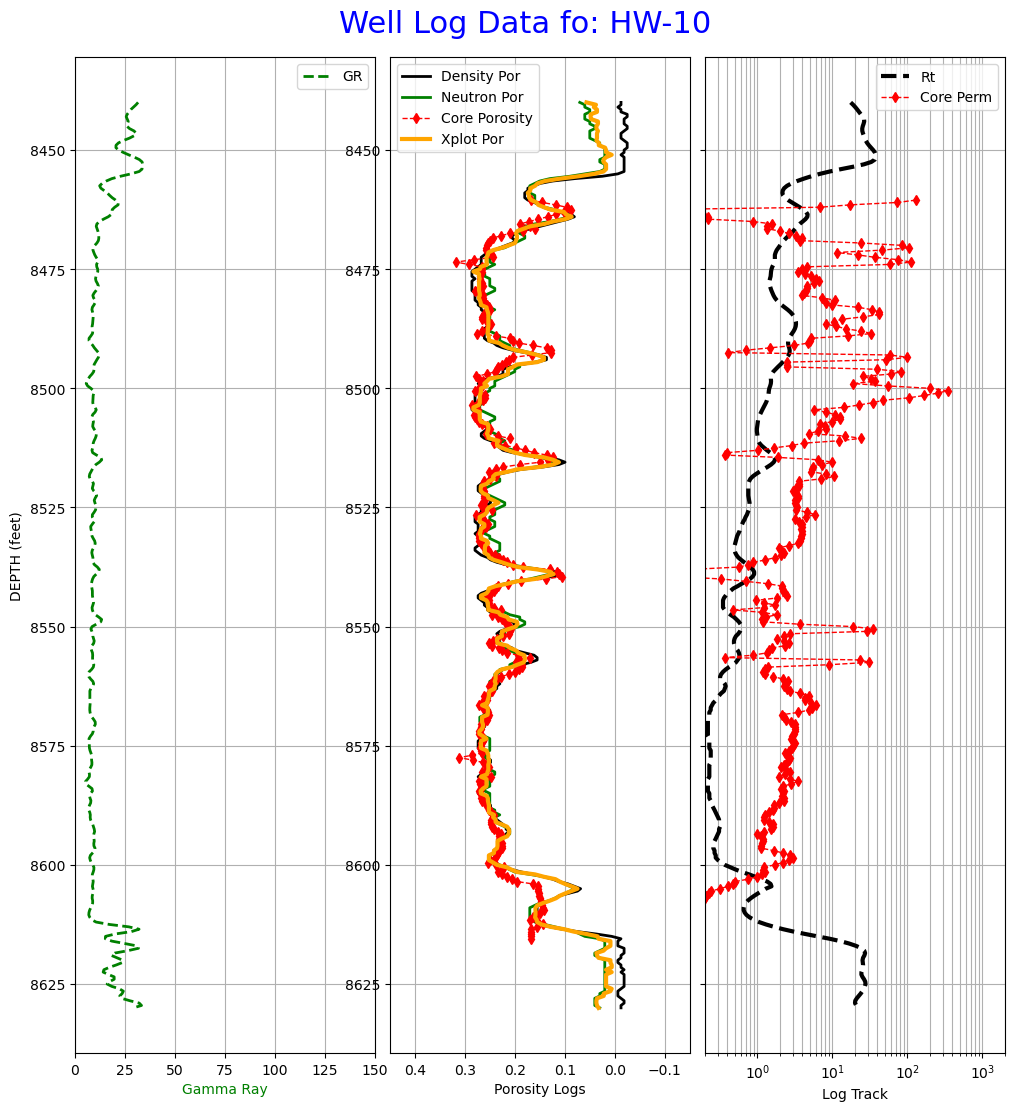

In [20]:
fig = plt.figure(figsize=(12,12))
wellname=las.well.well.value
fig.suptitle('Well Log Data fo: %s'%wellname, fontsize=22, color='blue')
fig.subplots_adjust(top=0.94, wspace=0.05, hspace =0.1)

gs = gridspec.GridSpec(1, 3)
ax0 = fig.add_subplot(gs[:,0])
ax1= fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])

y=np.array(deptharray)

# Porosity Logs
ax0.plot(gr, y,  '--',  color = 'green', lw=2, label= 'GR')
ax0.set_xlabel("Gamma Ray",color='green')
ax0.set_ylabel('DEPTH (feet)')
ax0.invert_yaxis()
ax0.grid(True)
ax0.set_xlim(0, 150)
ax0.legend()


# Porosity Logs
ax1.plot(porden, y, '-', color = 'black', lw=2, label= 'Density Por')
ax1.plot(CNL,    y, '-', color = 'green', lw=2, label= 'Neutron Por')
ax1.plot(cpor,   y, '--', color='red',marker = 'd', ms = 5, lw=1, label= 'Core Porosity')
ax1.plot(porarray, y, '-', color = 'orange', lw=3, label= 'Xplot Por')

ax1.set_xlabel("Porosity Logs",color='black')
ax1.invert_yaxis()
ax1.grid(True)
ax1.set_xlim(.45, -0.15)
ax1.legend()



# log track
ax2.semilogx(ild, y,'--',color = 'black', lw=3, label= 'Rt')
ax2.semilogx(cperm, y, '--', color='red',marker = 'd', ms = 5, lw=1, label= 'Core Perm')
ax2.set_xlabel("Log Track",color='black')
ax2.set_xlim(0.2, 2000)
ax2.tick_params(labelleft=False, top=False, labeltop=False, bottom=True, labelbottom=True)
ax2.legend()
ax2.invert_yaxis()
ax2.grid(True, which="both")





## Plot Definitions for most plots:

In [21]:
def Optimization_plot():

    fig = plt.figure(figsize=(18,15))
    #fig.suptitle('Optimized Petrophysical Results',fontsize=32,color='blue')
    #fig.subplots_adjust(top=0.94,wspace=0.05, hspace =0.1)
    wellname=las.well.well.value
    fig.suptitle('Optimized Petrophysical Results for: %s'%wellname, fontsize=32, color='blue')
    fig.subplots_adjust(top=0.94, wspace=0.05, hspace =0.1)

    gs = gridspec.GridSpec(1, 7)
    ax1 = fig.add_subplot(gs[:,0])
    ax2 = fig.add_subplot(gs[0,1])
    ax3 = fig.add_subplot(gs[0,2])
    ax4 = fig.add_subplot(gs[0,3])
    ax5 = fig.add_subplot(gs[0,4])
    ax6 = fig.add_subplot(gs[0,5])
    ax7 = fig.add_subplot(gs[0,6])

    y=np.array(deptharray)

    # Porosity Logs
    ax1.plot(porden, y,'-k',lw=2, label= 'Density Por')
    ax1.plot(CNL, y,'-g', lw=2, label= 'Neutron Por')
    ax1.plot(porarray, y,'-r',lw=3, label= 'kNN Chartbook Por')
    ax1.set_xlabel("Porosity Logs",color='black')
    ax1.set_ylabel('DEPTH (feet)')
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_xlim(.45, -0.15)
    ax1.fill_betweenx(y,CNL,porden, facecolor='#00ff00', hatch='--//')#, label= 'VOL_DOLO')
    ax1.legend()

    # Lithology
    quartz=np.array(VOL_QUARTZ)
    calcite=np.array(VOL_CALCITE)
    dolo=np.array(VOL_DOLO)
    illite=np.array(VOL_ILLITE)

    ax2.plot(illite, y,'-k',lw=2)
    ax2.plot(illite+quartz, y,'-k',lw=2)
    ax2.plot(illite+quartz+calcite, y,'-k',lw=1)
    ax2.plot(illite+quartz+calcite+dolo, y,'-k')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel(('Optimized Lithology'), color='black')
    ax2.fill_betweenx(y,0,illite, facecolor='#d1d1d1' ,hatch='.-.-',label= 'VOL_ILLITE')
    ax2.fill_betweenx(y,illite,illite+quartz, facecolor='#ffff00' ,hatch='..',label= 'VOL_QUARTZ')
    ax2.fill_betweenx(y,illite+quartz,illite+quartz+calcite, facecolor='#00ffff' ,hatch='++',label= 'VOL_CALCITE')
    ax2.fill_betweenx(y,illite+quartz+calcite,illite+quartz+calcite+dolo, facecolor='#00ff00', hatch='--//', label= 'VOL_DOLO')
    ax2.fill_betweenx(y,illite+quartz+calcite+dolo,1,color='black', label= 'PHIT')
    ax2.legend()
    #ax2=ax[2].twiny()
    ax2.invert_yaxis()
    ax2.grid(True)
    #ax2.set_ylabel('DEPTH (feet)')
    ax2.get_yaxis().set_visible(False)


    # Modeled Neutron Log
    ax3.plot(CNL, y,'-g', lw=3, label= 'Neutron Por')
    ax3.plot(tnph_theoretical, y,'-k',lw=1, label= 'Pred Neutron Por')
    ax3.set_xlabel("Modeled Neutron Log",color='black')
    ax3.set_xlim(.45, -0.15)
    ax3.fill_betweenx(y,CNL,tnph_theoretical, color='yellow')#, label= 'VOL_DOLO')
    #ax3.get_yaxis().set_visible(False)
    ax3.legend()
    ax3.invert_yaxis()
    ax3.grid(True)
    #ax3.set_ylabel('DEPTH (feet)')

    # Modeled Density Log
    ax4.plot(RHOB, y,'-r', lw=3, label= 'Bulk Density')
    ax4.plot(rhob_theoretical, y,'-k',lw=1, label= 'Pred Bulk Density')
    ax4.plot(rhoarray, y,'-g',lw=1, label= 'RHOMAA')

    ax4.set_xlabel("Modeled Bulk Density",color='black')
    ax4.set_xlim(2, 3)
    ax4.fill_betweenx(y,RHOB,rhob_theoretical, color='yellow')#, label= 'VOL_DOLO')
    ax4.fill_betweenx(y,error,0, color='red')#, label= 'VOL_DOLO')
    ax4.fill_betweenx(y,rhoarray,2.68, facecolor='#00ff00', hatch='--//', label= 'DOLO')
    #ax4.get_yaxis().set_visible(False)
    ax4.legend()
    ax4.invert_yaxis()
    ax4.grid(True)
    #ax4.set_ylabel('DEPTH (feet)')

    # Error Theoretical vs. Actual normalized logs
    ax5.plot(error, y,'-r', lw=1, label= 'Error')
    ax5.set_xlabel("Calculated Error",color='black')
    ax5.set_xlim(0, 1.0)
    ax5.fill_betweenx(y,error,0.15, color='pink')#, label= 'VOL_DOLO')
    #ax4.get_yaxis().set_visible(False)
    ax5.legend()
    ax5.invert_yaxis()
    ax5.grid(True)
    #ax4.set_ylabel('DEPTH (feet)')


    # Error Theoretical vs. Actual normalized logs
    ax6.plot(porarray, y,'-r', lw=1, label= 'PHIT')
    ax6.plot(bvw, y,'-k', lw=1, label= 'BVW')
    ax6.set_xlabel("Bulk Volume Calculations",color='black')
    ax6.set_xlim(0.5, 0.0)
    ax6.fill_betweenx(y,porarray,bvw, color='green')#, label= 'VOL_DOLO')
    ax6.fill_betweenx(y,bvw,0, color='cyan')#, label= 'VOL_DOLO')
    ax6.legend()
    ax6.invert_yaxis()
    ax6.grid(True)

    # Modeled Density Log
    ax7.plot(gr, y,'-g', lw=3, label= 'GR')
    ax7.plot(gr_theoretical, y,'-k',lw=1, label= 'Pred GR')
    ax7.set_xlabel("Modeled GR",color='black')
    ax7.set_xlim(0, 100)
    ax7.fill_betweenx(y,gr,gr_theoretical, color='yellow')#, label= 'VOL_DOLO')
    #ax7.fill_betweenx(y,error,0, color='red')#, label= 'VOL_DOLO')
    #ax4.get_yaxis().set_visible(False)
    ax7.legend()
    ax7.invert_yaxis()
    ax7.grid(True)
    #ax4.set_ylabel('DEPTH (feet)')



def Perm_plot():
    fig = plt.figure(figsize=(18,15))
    #fig.suptitle('Optimized Petrophysical Results with kNN Permeability',fontsize=32,color='blue')
    #fig.subplots_adjust(top=0.94,wspace=0.05, hspace =0.1)
    wellname=las.well.well.value
    fig.suptitle('Optimized Petrophysical Results with kNN Permeability: %s'%wellname, fontsize=32, color='blue')
    fig.subplots_adjust(top=0.94, wspace=0.05, hspace =0.1)

    gs = gridspec.GridSpec(1, 7)
    ax1 = fig.add_subplot(gs[:,0])
    ax2 = fig.add_subplot(gs[0,1])
    ax3 = fig.add_subplot(gs[0,2])
    ax4 = fig.add_subplot(gs[0,3])
    ax5 = fig.add_subplot(gs[0,4])
    ax6 = fig.add_subplot(gs[0,5])
    ax7 = fig.add_subplot(gs[0,6])

    y=np.array(deptharray)

    # Porosity Logs
    ax1.plot(porden, y,'-k',lw=2, label= 'Density Por')
    ax1.plot(CNL, y,'-g', lw=2, label= 'Neutron Por')
    ax1.plot(porarray, y,'-r',lw=3, label= 'kNN Chartbook Por')
    ax1.set_xlabel("Porosity Logs",color='black')
    ax1.set_ylabel('DEPTH (feet)')
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_xlim(.45, -0.15)
    ax1.fill_betweenx(y,CNL,porden, facecolor='#00ff00', hatch='--//')#, label= 'VOL_DOLO')
    ax1.legend()

    # Lithology
    quartz=np.array(VOL_QUARTZ)
    calcite=np.array(VOL_CALCITE)
    dolo=np.array(VOL_DOLO)
    illite=np.array(VOL_ILLITE)

    ax2.plot(illite, y,'-k',lw=2)
    ax2.plot(illite+quartz, y,'-k',lw=2)
    ax2.plot(illite+quartz+calcite, y,'-k',lw=1)
    ax2.plot(illite+quartz+calcite+dolo, y,'-k')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel(('Optimized Lithology'), color='black')
    ax2.fill_betweenx(y,0,illite, facecolor='#d1d1d1' ,hatch='.-.-',label= 'VOL_ILLITE')
    ax2.fill_betweenx(y,illite,illite+quartz, facecolor='#ffff00' ,hatch='..',label= 'VOL_QUARTZ')
    ax2.fill_betweenx(y,illite+quartz,illite+quartz+calcite, facecolor='#00ffff' ,hatch='++',label= 'VOL_CALCITE')
    ax2.fill_betweenx(y,illite+quartz+calcite,illite+quartz+calcite+dolo, facecolor='#00ff00', hatch='--//', label= 'VOL_DOLO')
    ax2.fill_betweenx(y,illite+quartz+calcite+dolo,1,color='black', label= 'PHIT')
    ax2.legend()
    #ax2=ax[2].twiny()
    ax2.invert_yaxis()
    ax2.grid(True)
    #ax2.set_ylabel('DEPTH (feet)')
    ax2.get_yaxis().set_visible(False)


    # Modeled Neutron Log
    ax3.plot(CNL, y,'-g', lw=3, label= 'Neutron Por')
    ax3.plot(tnph_theoretical, y,'-k',lw=1, label= 'Pred Neutron Por')
    ax3.set_xlabel("Modeled Neutron Log",color='black')
    ax3.set_xlim(.45, -0.15)
    ax3.fill_betweenx(y,CNL,tnph_theoretical, color='yellow')#, label= 'VOL_DOLO')
    #ax3.get_yaxis().set_visible(False)
    ax3.legend()
    ax3.invert_yaxis()
    ax3.grid(True)
    #ax3.set_ylabel('DEPTH (feet)')

    # Modeled Density Log
    ax4.plot(RHOB, y,'-r', lw=3, label= 'Bulk Density')
    ax4.plot(rhob_theoretical, y,'-k',lw=1, label= 'Pred Bulk Density')
    ax4.set_xlabel("Modeled Bulk Density",color='black')
    ax4.set_xlim(2, 3)
    ax4.fill_betweenx(y,RHOB,rhob_theoretical, color='yellow')#, label= 'VOL_DOLO')
    ax4.fill_betweenx(y,error,0, color='red')#, label= 'VOL_DOLO')
    #ax4.get_yaxis().set_visible(False)
    ax4.legend()
    ax4.invert_yaxis()
    ax4.grid(True)
    #ax4.set_ylabel('DEPTH (feet)')

    # Error Theoretical vs. Actual normalized logs
    ax5.plot(error, y,'-r', lw=1, label= 'Error')
    ax5.set_xlabel("Calculated Error",color='black')
    ax5.set_xlim(-1.0, 1.0)
    ax5.fill_betweenx(y,error,0.15, color='pink')#, label= 'VOL_DOLO')
    #ax4.get_yaxis().set_visible(False)
    ax5.legend()
    ax5.invert_yaxis()
    ax5.grid(True)
    #ax4.set_ylabel('DEPTH (feet)')


    # Error Theoretical vs. Actual normalized logs
    ax6.plot(porarray, y,'-r', lw=1, label= 'PHIT')
    ax6.plot(bvw, y,'-k', lw=1, label= 'BVW')
    ax6.set_xlabel("Bulk Volume Calculations",color='black')
    ax6.set_xlim(0.5, 0.0)
    ax6.fill_betweenx(y,porarray,bvw, color='green')#, label= 'VOL_DOLO')
    ax6.fill_betweenx(y,bvw,0, color='cyan')#, label= 'VOL_DOLO')
    ax6.legend()
    ax6.invert_yaxis()
    ax6.grid(True)

    # Permeability
    ax7.semilogx(perm, y,'-g', lw=1, label= 'Perm')
    ax7.semilogx(df_log['CORE_PERM'], y,'rd', lw=1, label= 'Core Perm')
    ax7.set_xlabel("kNN Permeability",color='green')
    ax7.set_xlim(0.2, 2000.0)
    ax7.legend()
    ax7.invert_yaxis()
    ax7.grid(True)




def Thomeer_plot():

    fig = plt.figure(figsize=(25,20))
    #fig.subplots_adjust(top=0.94,wspace=0.05, hspace =0.1)
    wellname=las.well.well.value
    fig.suptitle('kNN Permeability, GEV Parameters and PRT: %s'%wellname, fontsize=32, color='blue')
    fig.subplots_adjust(top=0.94, wspace=0.05, hspace =0.1)

    gs = gridspec.GridSpec(1, 8)
    ax1 = fig.add_subplot(gs[:,0])
    ax2 = fig.add_subplot(gs[0,1])
    ax3 = fig.add_subplot(gs[0,2])
    ax4 = fig.add_subplot(gs[0,3])
    ax5 = fig.add_subplot(gs[0,4])
    ax6 = fig.add_subplot(gs[0,5])
    ax7 = fig.add_subplot(gs[0,6])
    ax8 = fig.add_subplot(gs[0,7])

    y=np.array(deptharray)

    # Porosity Logs
    ax1.plot(porden, y,'-k',lw=2, label= 'Density Por')
    ax1.plot(CNL, y,'-g', lw=2, label= 'Neutron Por')
    ax1.plot(porarray, y,'-r',lw=3, label= 'kNN Chartbook Por')
    ax1.set_xlabel("Porosity Logs",color='black')
    ax1.set_ylabel('DEPTH (feet)')
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_xlim(.45, -0.15)
    ax1.fill_betweenx(y,CNL,porden, facecolor='#00ff00', hatch='--//')#, label= 'VOL_DOLO')
    ax1.legend()

    # Lithology
    quartz=np.array(VOL_QUARTZ)
    calcite=np.array(VOL_CALCITE)
    dolo=np.array(VOL_DOLO)
    illite=np.array(VOL_ILLITE)

    ax2.plot(illite, y,'-k',lw=2)
    ax2.plot(illite+quartz, y,'-k',lw=2)
    ax2.plot(illite+quartz+calcite, y,'-k',lw=1)
    ax2.plot(illite+quartz+calcite+dolo, y,'-k')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel(('Optimized Lithology'), color='black')
    ax2.fill_betweenx(y,0,illite, facecolor='#d1d1d1' ,hatch='.-.-',label= 'VOL_ILLITE')
    ax2.fill_betweenx(y,illite,illite+quartz, facecolor='#ffff00' ,hatch='..',label= 'VOL_QUARTZ')
    ax2.fill_betweenx(y,illite+quartz,illite+quartz+calcite, facecolor='#00ffff' ,hatch='++',label= 'VOL_CALCITE')
    ax2.fill_betweenx(y,illite+quartz+calcite,illite+quartz+calcite+dolo, facecolor='#00ff00', hatch='--//', label= 'VOL_DOLO')
    ax2.fill_betweenx(y,illite+quartz+calcite+dolo,1,color='black', label= 'PHIT')
    ax2.legend()
    #ax2=ax[2].twiny()
    ax2.invert_yaxis()
    ax2.grid(True)
    #ax2.set_ylabel('DEPTH (feet)')
    ax2.get_yaxis().set_visible(False)

 
    # BVocc Depth Track
    ax3.plot(BVocc2, y,'-k', lw=1, label= 'BVocc 2')
    ax3.plot(BVocc2+BVocc1,y,'-b',lw=1, label= 'BVocc 1')
    #ax3.plot(BVocc2+BVocc1,y,'-b',lw=1, label= 'BVocc 1')

    ax3.set_xlabel("Thomeer BVocc",color='black')
    ax3.set_xlim(50., 0.0)
    ax3.fill_betweenx(y,BVocc2,BVocc1+BVocc2, color='cyan')#, label= 'VOL_DOLO')
    ax3.fill_betweenx(y,0,bv2_est_knn, color='orange')#, label= 'VOL_DOLO')
    #ax3.get_yaxis().set_visible(False)
    ax3.legend()
    ax3.invert_yaxis()
    ax3.grid(True)

    # Thomeer Pd
    Pd1=np.array(pd1_est_knn)
    Pd2=np.array(pd2_est_knn)

    # Pd Track
    ax4.semilogx(Pd1, y,'-b', lw=1, label= 'Pd1')
    ax4.semilogx(Pd2, y,'-',color='orange', lw=1, label= 'Pd2')
    ax4.set_xlabel("Thomeer Pd",color='black')
    ax4.set_xlim(1, 10000)
    ax4.legend()
    ax4.invert_yaxis()
    ax4.grid(True)
    #ax4.set_ylabel('DEPTH (feet)')

    # Thomeer G
    G1=np.array(g1_est_knn)
    G2=np.array(g2_est_knn)

    # Thomeer G
    ax5.plot(G1, y,'-b', lw=1, label= 'G1')
    ax5.plot(G2, y,'-k', lw=1, label= 'G2')
    ax5.set_xlabel("Thomeer G",color='black')
    ax5.set_xlim(0, 2.0)
    ax5.legend()
    ax5.invert_yaxis()
    ax5.grid(True)

    # Error Theoretical vs. Actual normalized logs

    ax6.plot(porarray, y,'-r', lw=1, label= 'PHIT')
    ax6.plot(bvw, y,'-k', lw=1, label= 'BVW')
    ax6.set_xlabel("Bulk Volume Calculations",color='black')
    ax6.set_xlim(0.5, 0.0)
    ax6.fill_betweenx(y,porarray,bvw, color='green')#, label= 'VOL_DOLO')
    ax6.fill_betweenx(y,bvw,0, color='cyan')#, label= 'VOL_DOLO')
    ax6.legend()
    ax6.invert_yaxis()
    ax6.grid(True)

    # Permeability
    ax7.semilogx(perm, y,'-g', lw=2, label= 'Perm')
    ax7.semilogx(mode, y,'-r', lw=2, label= 'Mode of PTD')
    ax7.set_xlabel("kNN Permeability",color='black')
    ax7.set_xlim(0.1, 1000.0)
    ax7.legend()
    ax7.invert_yaxis()
    ax7.grid(True)

    # Rock Index or PRT
    ax8.plot(rock_index_knn, y,'-k', lw=1, label= 'PRT')
    ax8.set_xlabel("Petrophysical Rock Types",color='black')
    ax8.set_xlim(0., 7.0)
    ax8.fill_betweenx(y,rock_index_knn,7, color='cyan')
    ax8.legend()
    ax8.invert_yaxis()
    ax8.grid(True)

    ## Setting Up Shading for PRT
    left_col_value = 2
    right_col_value = 7
    span = abs(left_col_value - right_col_value)
    cmap = plt.get_cmap('rainbow')
    #cmap = plt.get_cmap('cool')

    color_index = np.arange(left_col_value, right_col_value, span / 6)
    #loop through each value in the color_index
    for index in sorted(color_index):
        index_value = (index - left_col_value)/span
        color = cmap(index_value) #obtain color for color index value
        ax8.fill_betweenx(y, rock_index_knn , right_col_value, where = rock_index_knn >= index,  color = color)






# 3) Saturation Calculations - interactive Pickett Plot with m&n and Rw sliders:

Column
    [0] Column
        [0] FloatSlider(end=3.0, format=PrintfTickFormatter(id='a4..., name="Cementation E..., start=1.0, step=0.01, value=2.0)
        [1] FloatSlider(end=3.0, format=PrintfTickFormatter(id='52..., name="Saturation Exponent '..., start=1.0, step=0.01, value=1.9)
        [2] FloatSlider(end=0.1, format=PrintfTickFormatter(id='7f..., name='Rw = ', start=0.01, step=0.001, value=0.017)
    [1] Row
        [0] Matplotlib(Figure, name='interactive00135')
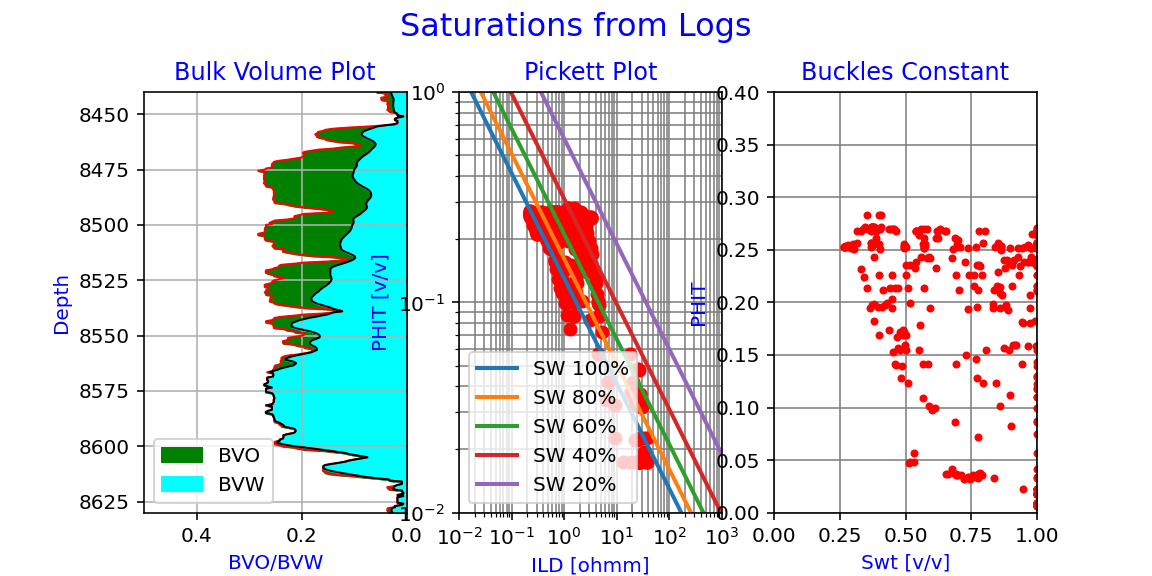

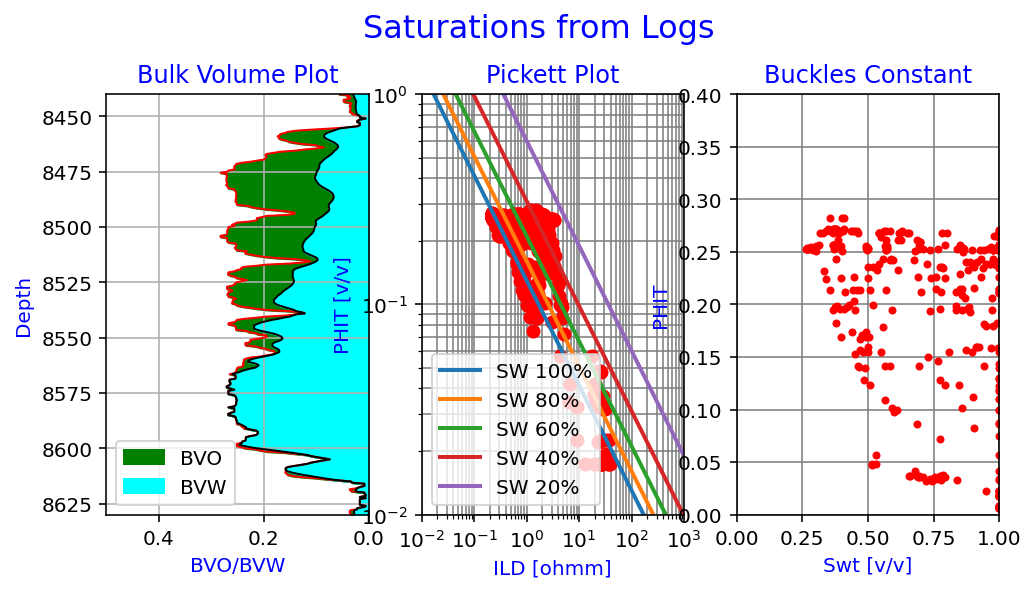

In [22]:
def Plot_Pickett( m, n, rw):

    bvw = []
    bvo=[]
    swt = []


    #log Data
    for k in range(0,len(df_log) ,1):

        TNPH    = CNL[k]
        RHOB2   = RHOB[k]
        GR      = gr[k]
        ILD     = ild[k]
        PHIT    = porarray[k]
        RHOMAA2 = rhoarray[k]

        PORDEN  = (RHOMAA2 - RHOB2)/(RHOMAA2 - FD)

        # =================================================================================
        #       Saturation Calculations
        # =================================================================================
        BVW = PHIT * ( (1/PHIT**m) * (rw/ILD) )**(1/n)

        if BVW > PHIT:
            BVW=PHIT
        else:
            BVW=BVW

        Swt = BVW/PHIT
        BVO = (PHIT*(1-Swt))
        bvo.append(BVO)
        swt.append(Swt)
        bvw.append(BVW)


    ######fig, axs = plt.subplot_mosaic([['left', 'right'],['middle','middle'],['bottom', 'bottom']])
    #fig, axs = plt.subplot_mosaic([['left', 'middle','right'],['bottom', 'bottom','bottom']])
    fig, axs = plt.subplot_mosaic([['left', 'middle','right']])

                              #constrained_layout=True)

    #fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(7, 7))
    fig.suptitle('Saturations from Logs',color='blue' , fontsize=16)
    fig.subplots_adjust(top=0.84,wspace=0.2, hspace =.15)
    fig.set_figwidth(8)
    fig.set_figheight(4)


    y=np.array(deptharray)

    # Depth Plot
    axs['left'].plot(porarray, y,'-r', lw=1)#, label= 'PHIT')
    axs['left'].plot(bvw, y,'-k', lw=1)#, label= 'BVW')
    axs['left'].set_title("Bulk Volume Plot",color='blue')
    axs['left'].set_xlabel("BVO/BVW",color='blue')
    axs['left'].set_ylabel("Depth",color='blue')
    axs['left'].set_xlim(0.5, 0.0)
    axs['left'].set_ylim(max(y), min(y))
    axs['left'].fill_betweenx(y,porarray,bvw, color='green', label= 'BVO')
    axs['left'].fill_betweenx(y,bvw,0, color='cyan', label= 'BVW')
    axs['left'].legend()
    axs['left'].grid()


    axs['right'].set_title('Buckles Constant', color = 'blue')
    axs['right'].plot(swt,porarray,'r.',label='')   
    axs['right'].set_xlim(0.0,1.0)
    axs['right'].set_ylim(0,0.4)
    axs['right'].set_ylabel('PHIT', color = 'blue')
    axs['right'].set_xlabel('Swt [v/v]', color = 'blue')
    axs['right'].grid(True, which='both',ls='-',color='gray')


    # Pickett Plot
    axs['middle'].loglog(ild,porarray, 'ro')
    axs['middle'].set_xlim(0.01,1000)
    axs['middle'].set_ylim(0.01,1)
    axs['middle'].set_title('Pickett Plot', color = 'blue')
    axs['middle'].set_ylabel('PHIT [v/v]', color = 'blue')
    axs['middle'].set_xlabel('ILD [ohmm]', color = 'blue')
    axs['middle'].grid()
    ######axs['middle'].xaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ######axs['middle'].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

    #calculate the saturation lines
    sw_plot=(1.0,0.8,0.6,0.4,0.2)
    phit_plot=(0.01,1)
    rt_plot=np.zeros((len(sw_plot),len(phit_plot)))

    for i in range (0,len(sw_plot)):
        for j in range (0,len(phit_plot)):
            rt_result=((rw)/(sw_plot[i]**n)*(1/(phit_plot[j]**m)))
            rt_plot[i,j]=rt_result
    for i in range(0,len(sw_plot)):
        axs['middle'].plot(rt_plot[i],phit_plot, linewidth=2, label='SW '+str(int(sw_plot[i]*100))+'%')
        axs['middle'].legend (loc='best')
    axs['middle'].grid(True, which='both',ls='-' ,color='gray')


    phit_buck_plot = (0.05,0.07,0.1,0.15,0.2,0.25,0.3,0.35)
    sw_buck_plot   = (1,0.75,0.5,0.33,0.25,0.2,0.16,0.14)

    #plt.show()
    
    # use return fig to see plots
    return fig






# =================================================================================
#       Archie Saturation Constants
# =================================================================================
rw = 0.017 # Rw from Pickett Plot
m  = 2.0
n  = 1.9
# =================================================================================



'''
Panel Version
'''

#float_slider = pn.widgets.FloatSlider(name='Float Slider', start=0, end=3.141, step=0.01, value=1.57)
m_slider  = pn.widgets.FloatSlider(name="Cementation Exponent 'm_cem' = ", start=1.00, end=3.00, step=0.01, value=m, format=PrintfTickFormatter(format='%.2f'))
n_slider  = pn.widgets.FloatSlider(name="Saturation Exponent 'n_sat' = ", start=1.00, end=3.00, step=0.01, value=n, format=PrintfTickFormatter(format='%.2f'))
rw_slider = pn.widgets.FloatSlider(name='Rw = ', start=0.01, end=0.1, step=0.001, value=rw, format=PrintfTickFormatter(format='%.3f'))


pn.interact(Plot_Pickett, m = m_slider, n = n_slider, rw = rw_slider)
#pane  = pn.interact(bvw_plot, m = m_slider, n = n_slider, rw = rw_slider, mslope = mslope_slider)


## Run following cell to **review all options and parameters** being used in this analysis:

In [23]:
print('Well Data being used with elev_meas_ref:', text.value)
print()
print('Neutron-Density Chart =', chart)
print()
print('lith_option =', lith_option)
print()
print('illite_option =', illite_option)
print()
print('Electrical Properties: m =',m_slider.value, ', n =',n_slider.value, ', Rw =',round(rw_slider.value,3) )
#print(swt)

Well Data being used with elev_meas_ref: las = lasio.read("./data/HW-10.las");elev_meas_ref = 397

Neutron-Density Chart = CNL_1pt1

lith_option = Calcite_Dolomite

illite_option = yes

Electrical Properties: m = 2.0 , n = 1.9 , Rw = 0.017


## **2nd START POINT**:

### Run Selected Cell and all Cells below from the Run Button.

In [24]:
m = m_slider.value
n = n_slider.value
rw = rw_slider.value

bvw = []
bvo=[]
swt = []


#log Data
for k in range(0,len(df_log) ,1):

    TNPH    = CNL[k]
    RHOB2   = RHOB[k]
    GR      = gr[k]
    ILD     = ild[k]
    PHIT    = porarray[k]
    RHOMAA2 = rhoarray[k]

    PORDEN  = (RHOMAA2 - RHOB2)/(RHOMAA2 - FD)

    # =================================================================================
    #       Saturation Calculations
    # =================================================================================
    BVW = PHIT * ( (1/PHIT**m) * (rw/ILD) )**(1/n)

    if BVW > PHIT:
        BVW=PHIT
    else:
        BVW=BVW

    Swt = BVW/PHIT
    BVO = (PHIT*(1-Swt))
    bvo.append(BVO)
    swt.append(Swt)
    bvw.append(BVW)


# 4) Optimizing Petrophysics solving for Lithology using Scipy Optimize:


#### a) Set lith_option to be either Quartz-Calcite-Dolomite or Calcite-Dolomite
#### b) Illite Option: include Illite as Clay (illite_option = 'yes') or Clay-free (illite_option = 'no')
## Scipy Optimization for Lithology:

### Refined by using chatGPT:

I have TNPH, RHOB , PHIT, RHOMAA2 and illite as known values.

I want to calculate 3 mineral weight percents that I want to solve for using optimization.

A theortetical RHOB can be calculated from the 3 mineral weight percents that we convert to volume percent by multiplying times (1-PHIT)

1) TNPH_theoretical = (0.247illite + 0*xy[0] + 0.05375*xy[1])*(1-PHIT) + PHIT

where we want TNPH = TNPH_Theoretical

2) RHOB_Theoretical = (2.52*illite + 2.65*xy[0] + 2.71*xy[1] + 2.847*xy[2])*(1-PHIT) + 1.19*PHIT) - RHOB

and RHOB = THOB_Theoretical

## This Optimization uses Neutron-Density-GR for the optimization on lithology from chatGPT:

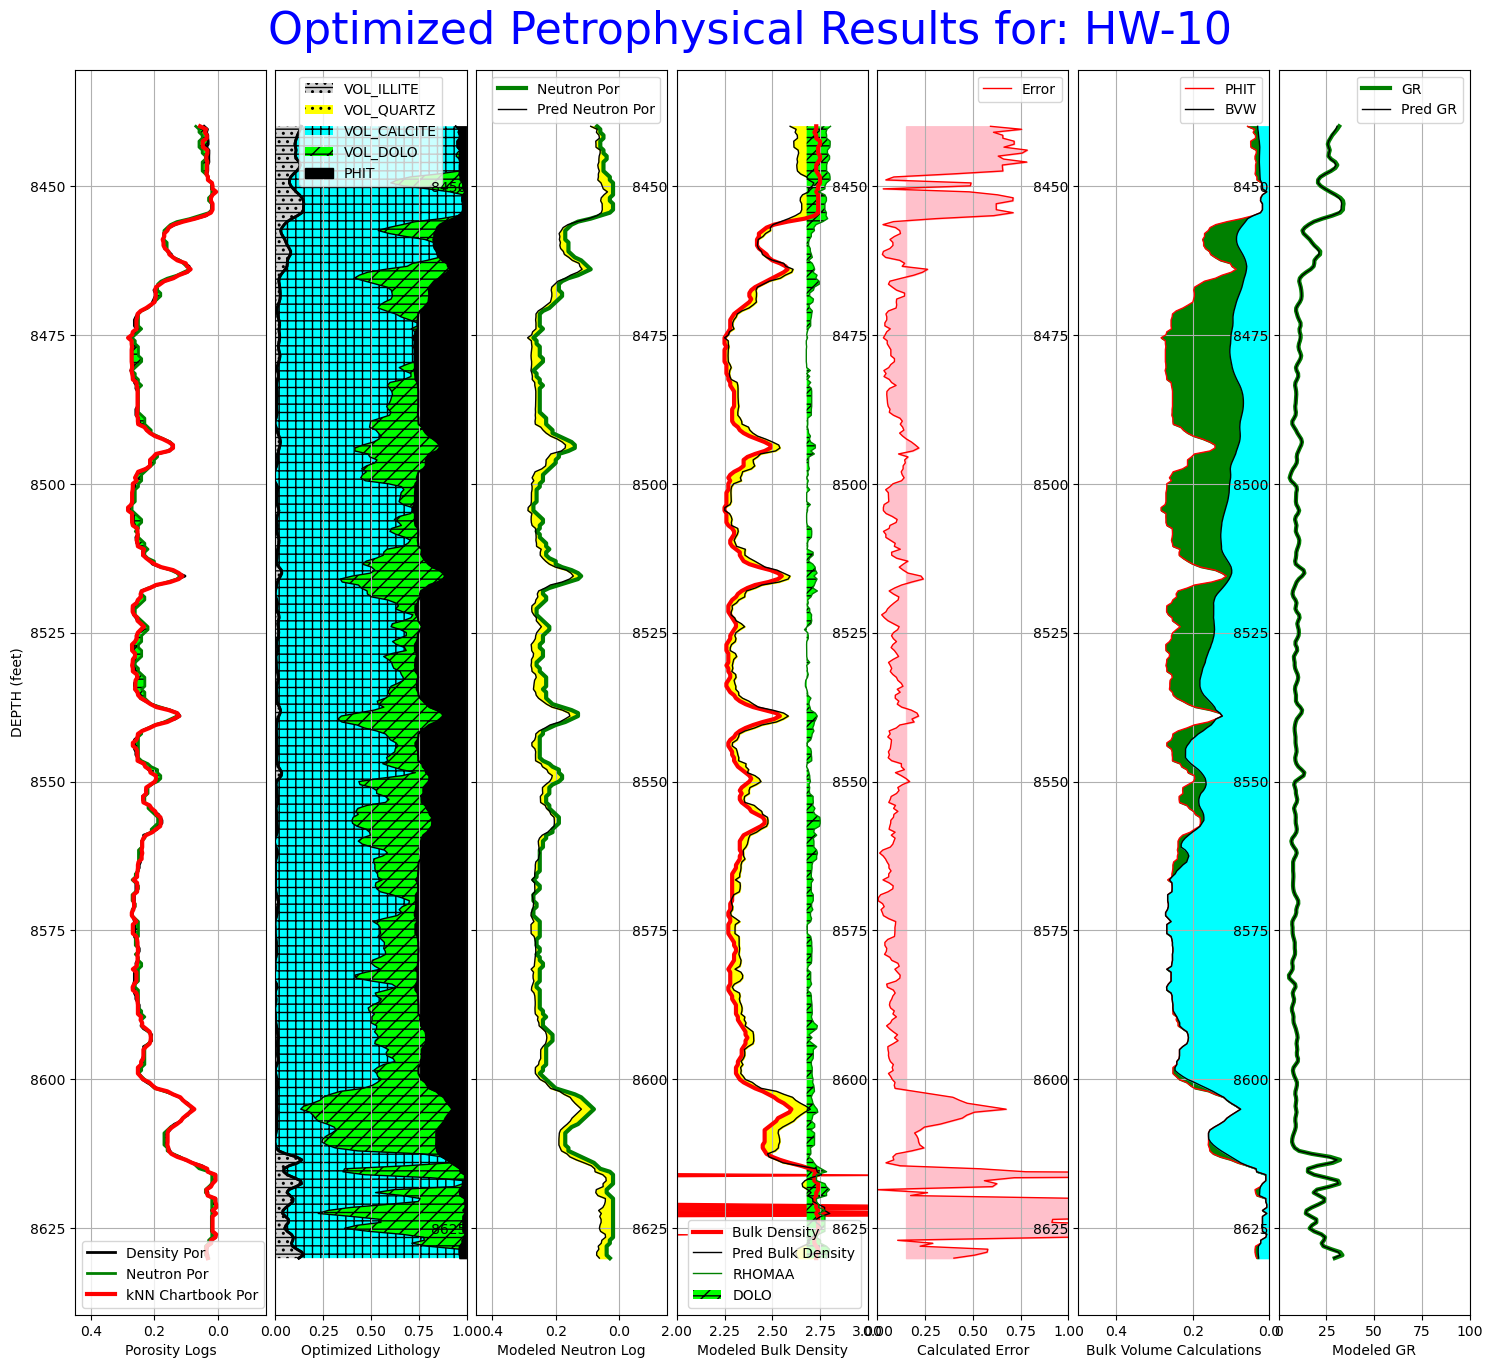

In [25]:


'''
# =============================================================================
# # ===========================================================================
# # #--------------------------------------------------------------------------
# ##
# ##            Start Code for Scipy Optimization using minimization
# ##
# # #--------------------------------------------------------------------------
# # ===========================================================================
# =============================================================================
'''
VOL_QUARTZ = []
VOL_CALCITE = []
VOL_DOLO = []
porden =[]
VOL_ILLITE = []
tnph = []
#bvw = []
#bvo=[]
#swt = []

rhob_theoretical = []
tnph_theoretical = []
gr_theoretical = []
error = []


'''
deptharray.append(Dep[k]);          # Taken from logs
RHOMAA_array.append(RHOMAA[k]);     # Taken from Log data
Porosity_array.append(Porosity[k]); # Taken from log data
porarray.append(por_est_knn);       # Calculated from logs
rhoarray.append(rhomatrix_est_knn); # Calculated from logs
'''

#log Data
for k in range(0,len(df_log) ,1):

    TNPH    = CNL[k]
    RHOB2   = RHOB[k]
    GR      = gr[k]
    ILD     = ild[k]
    PHIT    = porarray[k]
    RHOMAA2 = rhoarray[k]

    PORDEN  = (RHOMAA2 - RHOB2)/(RHOMAA2 - FD)

    # =================================================================================
    #       Saturation Calculations
    # =================================================================================
    #BVW = PHIT*((1/PHIT**m) * (rw/ILD) )**(1/n)

    #if BVW > PHIT:
    #    BVW=PHIT
    #else:
    #    BVW=BVW

    #Swt = BVW/PHIT
    #BVO = (PHIT*(1-Swt))
    #bvo.append(BVO)
    #swt.append(Swt)
    #bvw.append(BVW)

    # =================================================================================
    #       Illite Option Calculations
    # =================================================================================
    if illite_option == 'yes':
        vol_illite = -0.0424035 + 0.00562239*GR
        illite     = vol_illite/(1-PHIT)
    else:
        vol_illite = 0
        illite     = 0


    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # ##
    # ##         Scipy Optimization for Lithology of Calcite and Dolomite
    # ##
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================
    if lith_option == 'Calcite_Dolomite' :


        # Function to minimize
        def optimization_function(xy):
            RHOB_theoretical = (2.52*illite  + 2.71*xy[0] + 2.85*xy[1])*(1-PHIT) + 1.2*PHIT
            TNPH_theoretical = (0.247*illite + 0*xy[0] + 0.05375*xy[1])*(1-PHIT) + 1.0*PHIT
            GR_theoretical   = (160*illite + 11*xy[0] + 8*xy[1])*(1-PHIT) + 0.0*PHIT
            return (RHOB2 - RHOB_theoretical)**2 + (TNPH - TNPH_theoretical)**2 + (GR - GR_theoretical)**2

        # constraints

        # bounds
        #bnds = [ (0.05, 1), (0, 1 - 0.05 - 0.05)]
        # Bounds x is 0 to 1 and y is 0 to 1
        bnds = [(0.0, 1.0),(0.0, 1.0)]

                    # constraints
        cons = [
            {'type': 'eq',   'fun': lambda x: illite + x[0] + x[1] - 1}, # sum of xy[0], xy[1] must be equal to 1
            #{'type': 'eq',   'fun': lambda x: (illite + x[0] + x[1])*(1-PHIT) + PHIT - 1}, # sum of xy[0], xy[1] must be equal to 1
            {'type': 'ineq', 'fun': lambda x: x[0] - 0.001}, # xy[0] must be greater than or equal to 0.01
            {'type': 'ineq', 'fun': lambda x: x[1] - 0.001} # xy[1] must be greater than or equal to 0.01
            ]


        result = minimize(optimization_function, x0=[0, 0], constraints = cons, bounds=bnds, method='SLSQP', options={'maxiter': 1000})
        xy_optimal = result.x

        x = xy_optimal[0]
        y = xy_optimal[1]


        VOL_ILLITE.append(vol_illite)
        VOL_QUARTZ.append(0)
        VOL_CALCITE.append(x*(1-PHIT))
        VOL_DOLO.append(y*(1-PHIT))

        rhob_theoretical.append(( 2.52*illite  + 2.71*x   +   2.85*y)*(1-PHIT) + FD*PHIT)
        tnph_theoretical.append((0.247*illite  +  0*x     +   0.05375*y)*(1-PHIT) +    PHIT)
        gr_theoretical.append((160*illite +  11*x     +   8*y)        *(1-PHIT) + 0.0*PHIT)

        #print('Theoretical RHOB =' , round(rhob_theoretical, 3)  , ', RHOB =',RHOB2)


    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # ##
    # ##       Scipy Optimization for Lithology of Quartz, Cakcite and Dolomite
    # ##
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================
    elif lith_option == 'Quartz_Calcite_Dolomite' :
        if RHOMAA2 > 2.0:



            def optimization_function(xy):
                RHOB_theoretical = (2.52*illite + 2.65*xy[0] + 2.71*xy[1] + 2.85*xy[2])*(1-PHIT) + 1.2*PHIT
                TNPH_theoretical = (0.247*illite -0.05*xy[0] + 0*xy[1] + 0.05375*xy[2])*(1-PHIT) + 1.0*PHIT
                GR_theoretical   = (160*illite + 1*xy[0] + 11*xy[1] + 8*xy[2])*(1-PHIT) + 0.0*PHIT
                return (RHOB2 - RHOB_theoretical)**2 + (TNPH - TNPH_theoretical)**2 + (GR - GR_theoretical)**2

            # constraints

            # bounds
            bnds = [(0, 1), (0, 1), (0, 1)]

            # constraints
            cons = [
                {'type': 'eq', 'fun': lambda x: illite + x[0] + x[1] + x[2] - 1}, # sum of xy[0], xy[1], xy[2] must be equal to 1
                {'type': 'ineq', 'fun': lambda x: x[0] - 0.001}, # xy[0] must be greater than or equal to 0.01
                {'type': 'ineq', 'fun': lambda x: x[1] - 0.001}, # xy[1] must be greater than or equal to 0.01
                {'type': 'ineq', 'fun': lambda x: x[2] - 0.001}  # xy[1] must be greater than or equal to 0.01
            ]


            result = minimize(optimization_function, x0=[0, 0, 0], constraints=cons, bounds=bnds, method='SLSQP', options={'maxiter': 1000})

            xy_optimal = result.x


            x = xy_optimal[0]
            y = xy_optimal[1]
            z = xy_optimal[2]



            VOL_ILLITE.append(vol_illite)
            VOL_QUARTZ.append(x*(1-PHIT))
            VOL_CALCITE.append(y*(1-PHIT))
            VOL_DOLO.append(z*(1-PHIT))

            rhob_theoretical.append((2.520*illite + 2.65*x + 2.71*y + 2.85*z)*(1-PHIT) + 1.2*PHIT)
            tnph_theoretical.append((0.247*illite - 0.05*x + 0.0*y  + 0.05373*z)*(1-PHIT) + 1.0*PHIT)
            gr_theoretical.append((160*illite + 1*x +  11*y     +   8*z)        *(1-PHIT) + 0.0*PHIT)
            #print('Theoretical RHOB =' , round(rhob_theoretical, 3)  , ', RHOB =',RHOB2)



        else:

            VOL_ILLITE.append(vol_illite)
            VOL_QUARTZ.append(1-PHIT)
            VOL_CALCITE.append(0)
            VOL_DOLO.append(0)

            rhob_theoretical.append(0)
            tnph_theoretical.append(0)
            error.append(0)


    porden.append(PORDEN)
    tnph.append(TNPH)

    rhob_norm = (RHOB[k] - 1.9)/(3.0 - 1.9)
    rhob_norm_theo = (rhob_theoretical[k] - 1.9)/(3.0 - 1.9)
    tnph_norm = ( CNL[k] - (-0.05))/(0.6 - (-0.05))
    tnph_norm_theo = (tnph_theoretical[k] - (-0.05))/(0.6 - (-0.05))
    gr_norm = ( gr[k] -  0)/(150 - 0)
    gr_norm_theo = (gr_theoretical[k] - 0)/(150 - 0)


    error.append(0.333*abs((rhob_norm-rhob_norm_theo)+(tnph_norm-tnph_norm_theo)+(gr_norm-gr_norm_theo))/(PHIT))

'''
# =============================================================================
#      Display Optimization Petrophysics
# ============================================================================='''
Optimization_plot()

# 5) Permeability Estimations from Knn:
### Import the Permeability calibration data and then make the Perm estimations.

In [26]:
#!/usr/bin/env python3
# python loglan

# =============================================================================
# # ===========================================================================
# # #--------------------------------------------------------------------------
# # #        Read in Reference HW data (_r) from Excel file
# # #        Read in the reference Core data
# # #
# # #--------------------------------------------------------------------------
# # ===========================================================================
# =============================================================================

#read the Excel .xlsx file
file = r'./data/HW_Phit_Rhob_GR_Perm.xlsx'
core_data = pd.read_excel(file,index_col=False)
core_data = core_data.replace(-999.25,np.nan)


Por_r   = core_data['PHIT']
Rhob_r  = core_data['RHOB']
GR_r    = core_data['GR']
Kair_r  = np.log10(core_data['PERMEABILITY'])

#print(gr)

## kNN Nearest Neighbors estimation of Permeability:

381


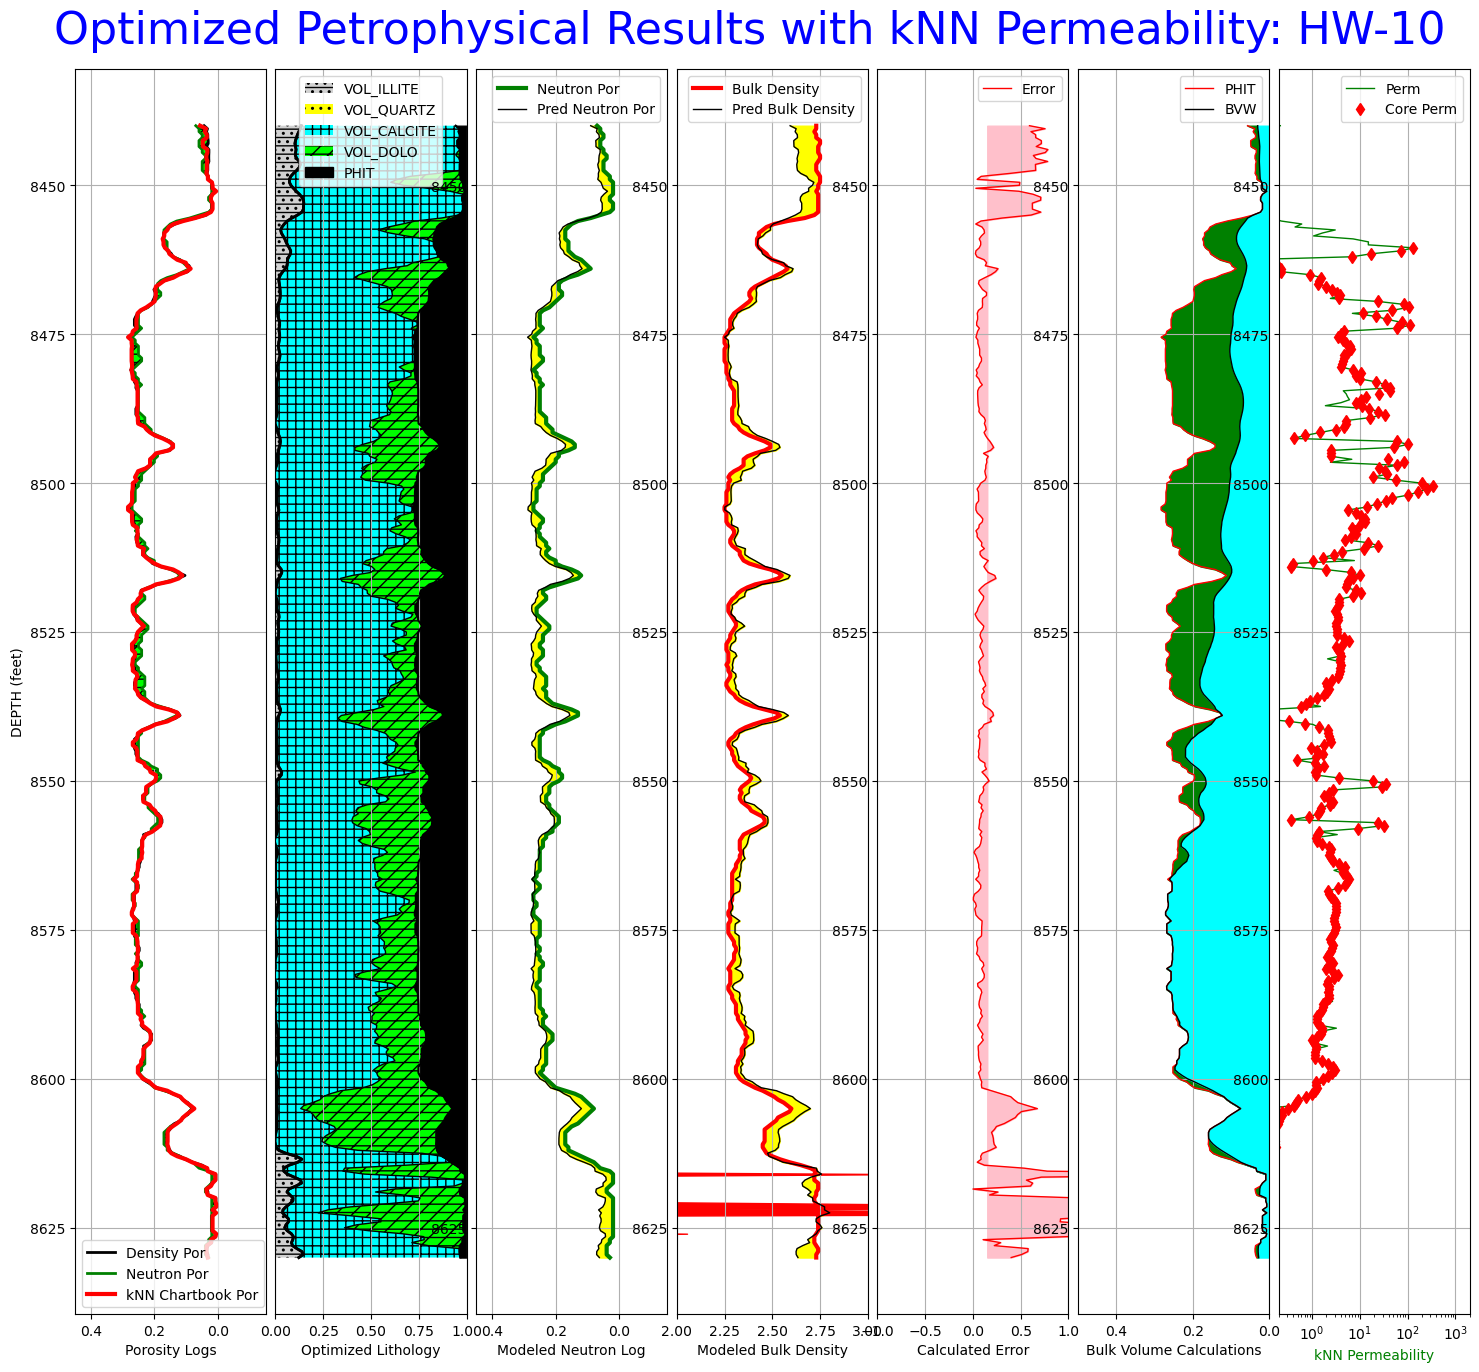

In [27]:
n_neighbors = 5

# =============================================================================
# # ===========================================================================
# # #--------------------------------------------------------------------------
# # #
# # #            This is the beginnin of kNN for Permeability Estimations
# # #
# # #--------------------------------------------------------------------------
# # ===========================================================================
# =============================================================================

#porarray.append(por_est_knn);       # Calculated Chartbook Porosity
#permarray  = []
perm = []

#print(len(porarray),len(swt))



# Load data from geolog
#while geolog.getrow():
for k in range(0,len(df_log) ,1):


    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #            Read in log data
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================
    Por = porarray[k]
    Rhob = RHOB[k]
    GR   = gr[k]


    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #            This is the beginnin of kNN for Permeability Estimations
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================

    permarray  = []

    inv_dist_array = []
    distance_knn_array = []


    #for k in range(0,len(NMR_data) ,1):
    por_norm = ((Por -  0)/(.4 - 0))
    rhob_norm = (Rhob-2)/(3-2)
    gr_norm   = (GR - 0)/(100-0)

    dist_inv    = []
    dist_phi    = []
    dist_rhob   = []
    dist_gr     = []
    Perm_weight = []
    Por_r_norm  = []
    Rhob_r_norm = []
    GR_r_norm   = []

    dist_inv_total = 0
    Perm_total     = 0



    #this is the reference_data being used with kNN
    for i in range(0,len(core_data),1):

        # Normalize the core reference data of Por_r and swt_r
        Por_r_norm.append((Por_r[i]   -  0)/(0.4 - 0))
        Rhob_r_norm.append((Rhob_r[i] -  2)/(3   - 2))
        GR_r_norm.append((GR_r[i]     -  0)/(100 - 0))


        # Compute Euclidian Distance inverse distance
        dist_phi.append(abs(por_norm - Por_r_norm[i]))
        dist_rhob.append(abs(rhob_norm - Rhob_r_norm[i]))
        dist_gr.append(abs(gr_norm - GR_r_norm[i]))
        dist_inv.append(1/(math.sqrt(dist_phi[i]**2 + dist_rhob[i]**2 + dist_gr[i]**2) + 0.0000001))

        # Calculalte inverse distance weights for perm
        Perm_weight.append(dist_inv[i]  * Kair_r[i])
        inv_dist_array.append(dist_inv[i]);  # add items

        # =============================================================================
        ###                    KNN Array for all data
        # # ===========================================================================
        # # #--------------------------------------------------------------------------
        distance_knn_array = [dist_inv, Perm_weight]
        #
        # # #--------------------------------------------------------------------------
        # # ===========================================================================
        # =============================================================================

    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #               Transpose and Sort kNN array
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================

    #knn_array = np.transpose array
    knn_array = np.transpose(distance_knn_array)

    #matsor x[x[:,column].argsort()[::-1]] and -1 us reverse order
    mat_sort = knn_array[knn_array[:,0].argsort()[::-1]] #firt column reverse sort (-1)

    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #               Calculate knn GEV Parameters
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================
    #------------------------------------------------------------------------------
    #    Number of nearest Neighbors set in loglan constans
    #------------------------------------------------------------------------------
    #n_neighbors = 3
    #------------------------------------------------------------------------------

    dist_inv_total_knn = 0
    Perm_total_knn = 0


    #kNN Estimates for first n rows

    for i in range(0,n_neighbors,1):
        dist_inv_total_knn = dist_inv_total_knn + mat_sort[i][0]
        Perm_total_knn  = Perm_total_knn + mat_sort[i][1]

    #back to k values and calculate estimations now
    perm_est_knn = (10**(Perm_total_knn  / dist_inv_total_knn))

    if perm_est_knn < 0.001:
        perm_est_knn = 0.001

    perm.append(perm_est_knn)

print(len(perm))

'''
# =============================================================================
#      Display Optimization Petrophysics with Permeability
# ============================================================================='''
Perm_plot()

# 6) Estimate GEV Parameters using Knn to Calculate Capillary Pressure Saturations:
### Read in Costa HPMI GEV Parameter Reference Calibration Data.

## We are importing log10 of mu1 and mu2 and calculating the log10 of Mode_xi. 

In [28]:
# Read the Excel file
file = r'./data/Sample_Optimization_Results_Optimization_GEV_CDF_PDF_Aug8.xlsx'
GEV_core_data = pd.read_excel(file, index_col=False)
GEV_core_data = GEV_core_data.replace(-999.25, np.nan)

# Extract relevant columns
Permeability_r = GEV_core_data['Permeability']
Porosity_r = GEV_core_data['Porosity'] / 100  # Convert percentage to fraction
w1_r = GEV_core_data['w1']
mu1_r = GEV_core_data['mu1']
sigma1_r = GEV_core_data['sigma1']
mu2_r = GEV_core_data['mu2']
sigma2_r = GEV_core_data['sigma2']

# Calculate Mode using xi = -0.5 and this is still the log10(Mode)
xi = -0.5
Mode_xi = (mu1_r + sigma1_r * (((1 + xi)**(-xi) - 1) / xi))



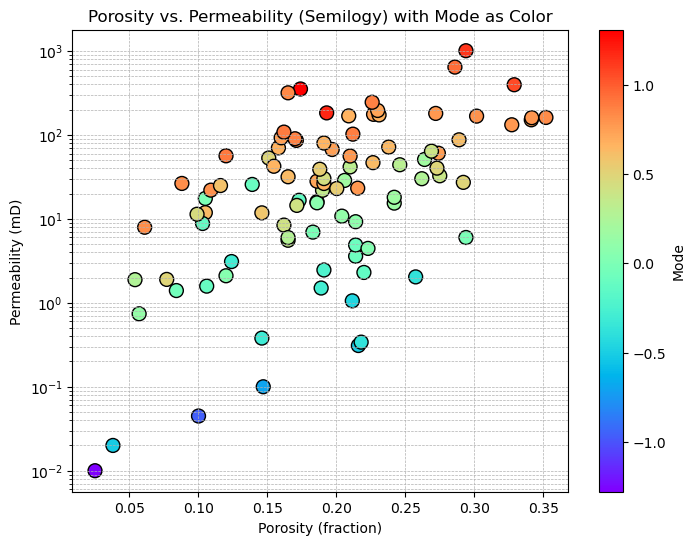

In [29]:
# Create the semilogy scatter plot with Mode as the color
plt.figure(figsize=(8, 6))
sc = plt.scatter(Porosity_r, Permeability_r, c=Mode_xi, cmap='rainbow', edgecolor='k', s=100)
plt.colorbar(sc, label='Mode')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.xlabel('Porosity (fraction)')
plt.ylabel('Permeability (mD)')
plt.title('Porosity vs. Permeability (Semilogy) with Mode as Color')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid lines
plt.show()

## kNN used to Estimate GEV Parameters (w, mu and sigma):

In [30]:


por_min = 0
por_max = 0.4
perm_min = -4
perm_max = 4

w1_est_knn  = []
mu1_est_knn = []
sigma1_est_knn = []

w2_est_knn = []
mu2_est_knn  = []
sigma2_est_knn = []

mode=[]



def most_frequent(List):
    occurence_count = Counter(List)
    return occurence_count.most_common(1)[0][0]


#List = [mat_sort[0][7],mat_sort[1][7],mat_sort[2][7],mat_sort[3][7],mat_sort[4][7]]


#mode = math.exp(-1.15*g1_est_knn) * (214/pd1_est_knn)
#Rock_Index_est_knn = int(Rock_Index_total_knn / n_neighbors)


for k in range(0,len(df_log) ,1):

   # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #            Read in log data
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================

    #phit/0.95 is an approximation for ambient core porosity to query the Rosetta Stone data
    Por = porarray[k]/0.95
    Perm = perm[k]


    # =============================================================================
     # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #            This is the beginning of kNN for GEV parameter Estimations
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================

    #normalized Geolog well Porosity and Permeability data
    por_norm  = (Por-por_min) / (por_max - por_min)
    perm_norm = (np.log10(Perm) - perm_min) / (perm_max - perm_min)

    # =============================================================================
    # #----------------------------------------------------------------------------
    # #
    # #              ESTIMATE GEV PARAMETERS FOR BOTH PORE SYSTEMS
    # #
    # #----------------------------------------------------------------------------
    # =============================================================================

    dist_inv = []
    dist_phi = []
    dist_lperm = []
    w1_weight = []
    mu1_weight = []
    sigma1_weight = []
    
    mu2_weight = []
    sigma2_weight = []


    
    dist_inv_total=0
    w1_total  = 0
    mu1_total = 0
    sigma1_total = 0
    mu2_total  = 0
    sigma2_total = 0




    inv_dist_array = []
    #distance_knn_array = [rows,columns]
    distance_knn_array = []


    #------------------------------------------------------------------
    #               Estimate all GEV Parameters for *_est values
    #-------------------------------------------------------------------

    Porosity_norm     = []
    Permeability_norm = []


    '''
    This is the Reference Data being used here
    '''
    for i in range(0,len(GEV_core_data),1):

        Porosity_norm.append((Porosity_r[i] - por_min) / (por_max - por_min))
        Permeability_norm.append((np.log10(Permeability_r[i]) - perm_min) / (perm_max - perm_min))

        #Euclidian Distance
        dist_phi.append(   abs(por_norm  - Porosity_norm[i]    ))
        dist_lperm.append( abs(perm_norm - Permeability_norm[i]))
        dist_inv.append( 1  /  math.sqrt(  dist_phi[i]**2 + dist_lperm[i]**2)  )


        #calculalte weights for each
        w1_weight.append(dist_inv[i]  * w1_r[i])
        mu1_weight.append(dist_inv[i] * mu1_r[i])
        sigma1_weight.append(dist_inv[i] * sigma1_r[i])
        mu2_weight.append(dist_inv[i]  * mu2_r[i])
        sigma2_weight.append(dist_inv[i] * sigma2_r[i])
        #Rock_Index_weight.append(dist_inv[i] * Rock_Index[i])



        inv_dist_array.append(dist_inv[i]);  # add items

    # =============================================================================
    ###                    Create the KNN Array
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
        distance_knn_array = [dist_inv, w1_weight, mu1_weight, sigma1_weight, mu2_weight, sigma2_weight]
    #        distance_knn_array = [Permeability, Porosity, G1, PD1, BV1, G2, PD2, BV2]
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================
    #xnorm=np.array(Porosity_norm)
    #ynorm=np.array(Permeability_norm)


    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #               Transpose and Sort the kNN array
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================

    #knn_array = np.transpose array
    knn_array = np.transpose(distance_knn_array)
    #print(knn_array)

    #Sort array from large to low by column 0 which is dist_inv
    #xknn=np.array(knn_array)

    #matsor x[x[:,column].argsort()[::-1]] and -1 us reverse order
    mat_sort = knn_array[knn_array[:,0].argsort()[::-1]] #firt column reverse sort (-1)
    #mat_sort = x[x[:,1].argsort()[::-1]]
    #mat_sort = x[x[:,2].argsort()[::-1]]



    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #               Calculate knn GEV Parameters
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================


    #------------------------------------------------------------------------------
    #    Number of nearest Neighbors
    #------------------------------------------------------------------------------
    n_neighbors = 3
    #------------------------------------------------------------------------------

    dist_inv_total_knn = 0
    w1_total_knn = 0
    mu1_total_knn = 0
    sigma1_total_knn = 0
    mu2_total_knn = 0
    sigma2_total_knn = 0
    #Rock_Index_total_knn = 0



    #kNN Estimates for first 3 rows
    #dist_inv_total = mat_sort[0][0] + mat_sort[1][0] + mat_sort[2][0]
    for i in range(0,n_neighbors,1):
        dist_inv_total_knn = dist_inv_total_knn + mat_sort[i][0]
        w1_total_knn  = w1_total_knn + mat_sort[i][1]
        mu1_total_knn = mu1_total_knn + mat_sort[i][2]
        sigma1_total_knn = sigma1_total_knn + mat_sort[i][3]
        mu2_total_knn  = mu2_total_knn + mat_sort[i][4]
        sigma2_total_knn = sigma2_total_knn + mat_sort[i][5]
        #Rock_Index_total_knn = Rock_Index_total_knn + mat_sort[i][7]
        #print(mat_sort[i][7])


    # Estimate GEV parameters to be written into Geolog well
    w1_est_knn.append(w1_total_knn  / dist_inv_total_knn)
    w2_est_knn.append(1 - w1_total_knn  / dist_inv_total_knn)
    mu1_est_knn.append( mu1_total_knn / dist_inv_total_knn)
    sigma1_est_knn.append( sigma1_total_knn / dist_inv_total_knn)
    mu2_est_knn.append( mu2_total_knn  / dist_inv_total_knn)
    sigma2_est_knn.append( sigma2_total_knn / dist_inv_total_knn)
    #bv2_est_knn.append( BV2_total_knn / dist_inv_total_knn)
    #mode.append(  math.exp(-1.15*g1_est_knn[k]) * (214/pd1_est_knn[k]) )




print(len(w1_est_knn))
print(len(sigma2_est_knn))
print(len(w2_est_knn))

#print(mu1_est_knn)

381
381
381


## Create Pore Size Distribution:

In [31]:
from scipy.stats import genextreme
import numpy as np

# Initialize arrays to store results for all depths
micronarray_all = []
swarray_all = []
pdf_all = []
Mode_xi = []
Perm_Mode_xi = []


# Constants
IFTheta = 367  # Interfacial tension constant
increment_factor = 1.5  # Pc increment factor
starting_Pc = 1.61  # Starting capillary pressure
num_Pc_levels = 28  # Number of Pc levels to calculate

# Loop through each depth level
for i in range(len(mu1_est_knn)):  # Iterate through all samples/depths
    
    # Initialize arrays for the current depth
    micronarray = []
    swarray = []  # Reset for each depth
    
    # Initialize variables
    Pc = starting_Pc
    
    # Loop through Pc levels
    for j in range(num_Pc_levels):
        # Calculate microns (radius)
        Rc = 2 * IFTheta * 0.147 / Pc  # Convert Pc to radius in microns

        Rc_log = np.log10(Rc)  # or -log10(Rc), depending on your convention
        Sw1 = np.clip(
            w1_est_knn[i] * genextreme.cdf(Rc_log, c=0.5, loc=mu1_est_knn[i], scale=sigma1_est_knn[i]) +
            w2_est_knn[i] * genextreme.cdf(Rc_log, c=0.5, loc=mu2_est_knn[i], scale=sigma2_est_knn[i]),
            0,
            1
        )
 

        
        #Sw1 = np.sum(genextreme.cdf(np.log10(Rc), 0.5, [mu1, mu2], [sigma1, sigma2]) * [w1, w2])
        
        # Append values for the current Pc level
        swarray.append(-1*Sw1)
        micronarray.append(Rc)
        
        # Update Pc for the next increment
        Pc *= increment_factor
    
    # Calculate the derivative (PDF) of Sw1
    # Use np.diff to compute differences between consecutive Sw1 values
    #pdf = np.diff(swarray) / np.diff(micronarray)  # Derivative of Sw1 w.r.t Rc
    #pdf = np.insert(pdf, 0, 0)  # Prepend 0 to match the length of swarray

    xi = -0.5
    Mode_xi.append(mu1_est_knn[i] + sigma1_est_knn[i] * (((1 + xi)**(-xi) - 1)/xi))


    pdf = np.diff(swarray)
    pdf = np.insert(pdf,0,0)

    
    # Store results for the current depth
    swarray_all.append(swarray)
    micronarray_all.append(micronarray)
    pdf_all.append(20*pdf)
    dbvarray_all = pdf_all

# At this point, swarray_all, micronarray_all, and pdf_all are all consistent and structured for each depth


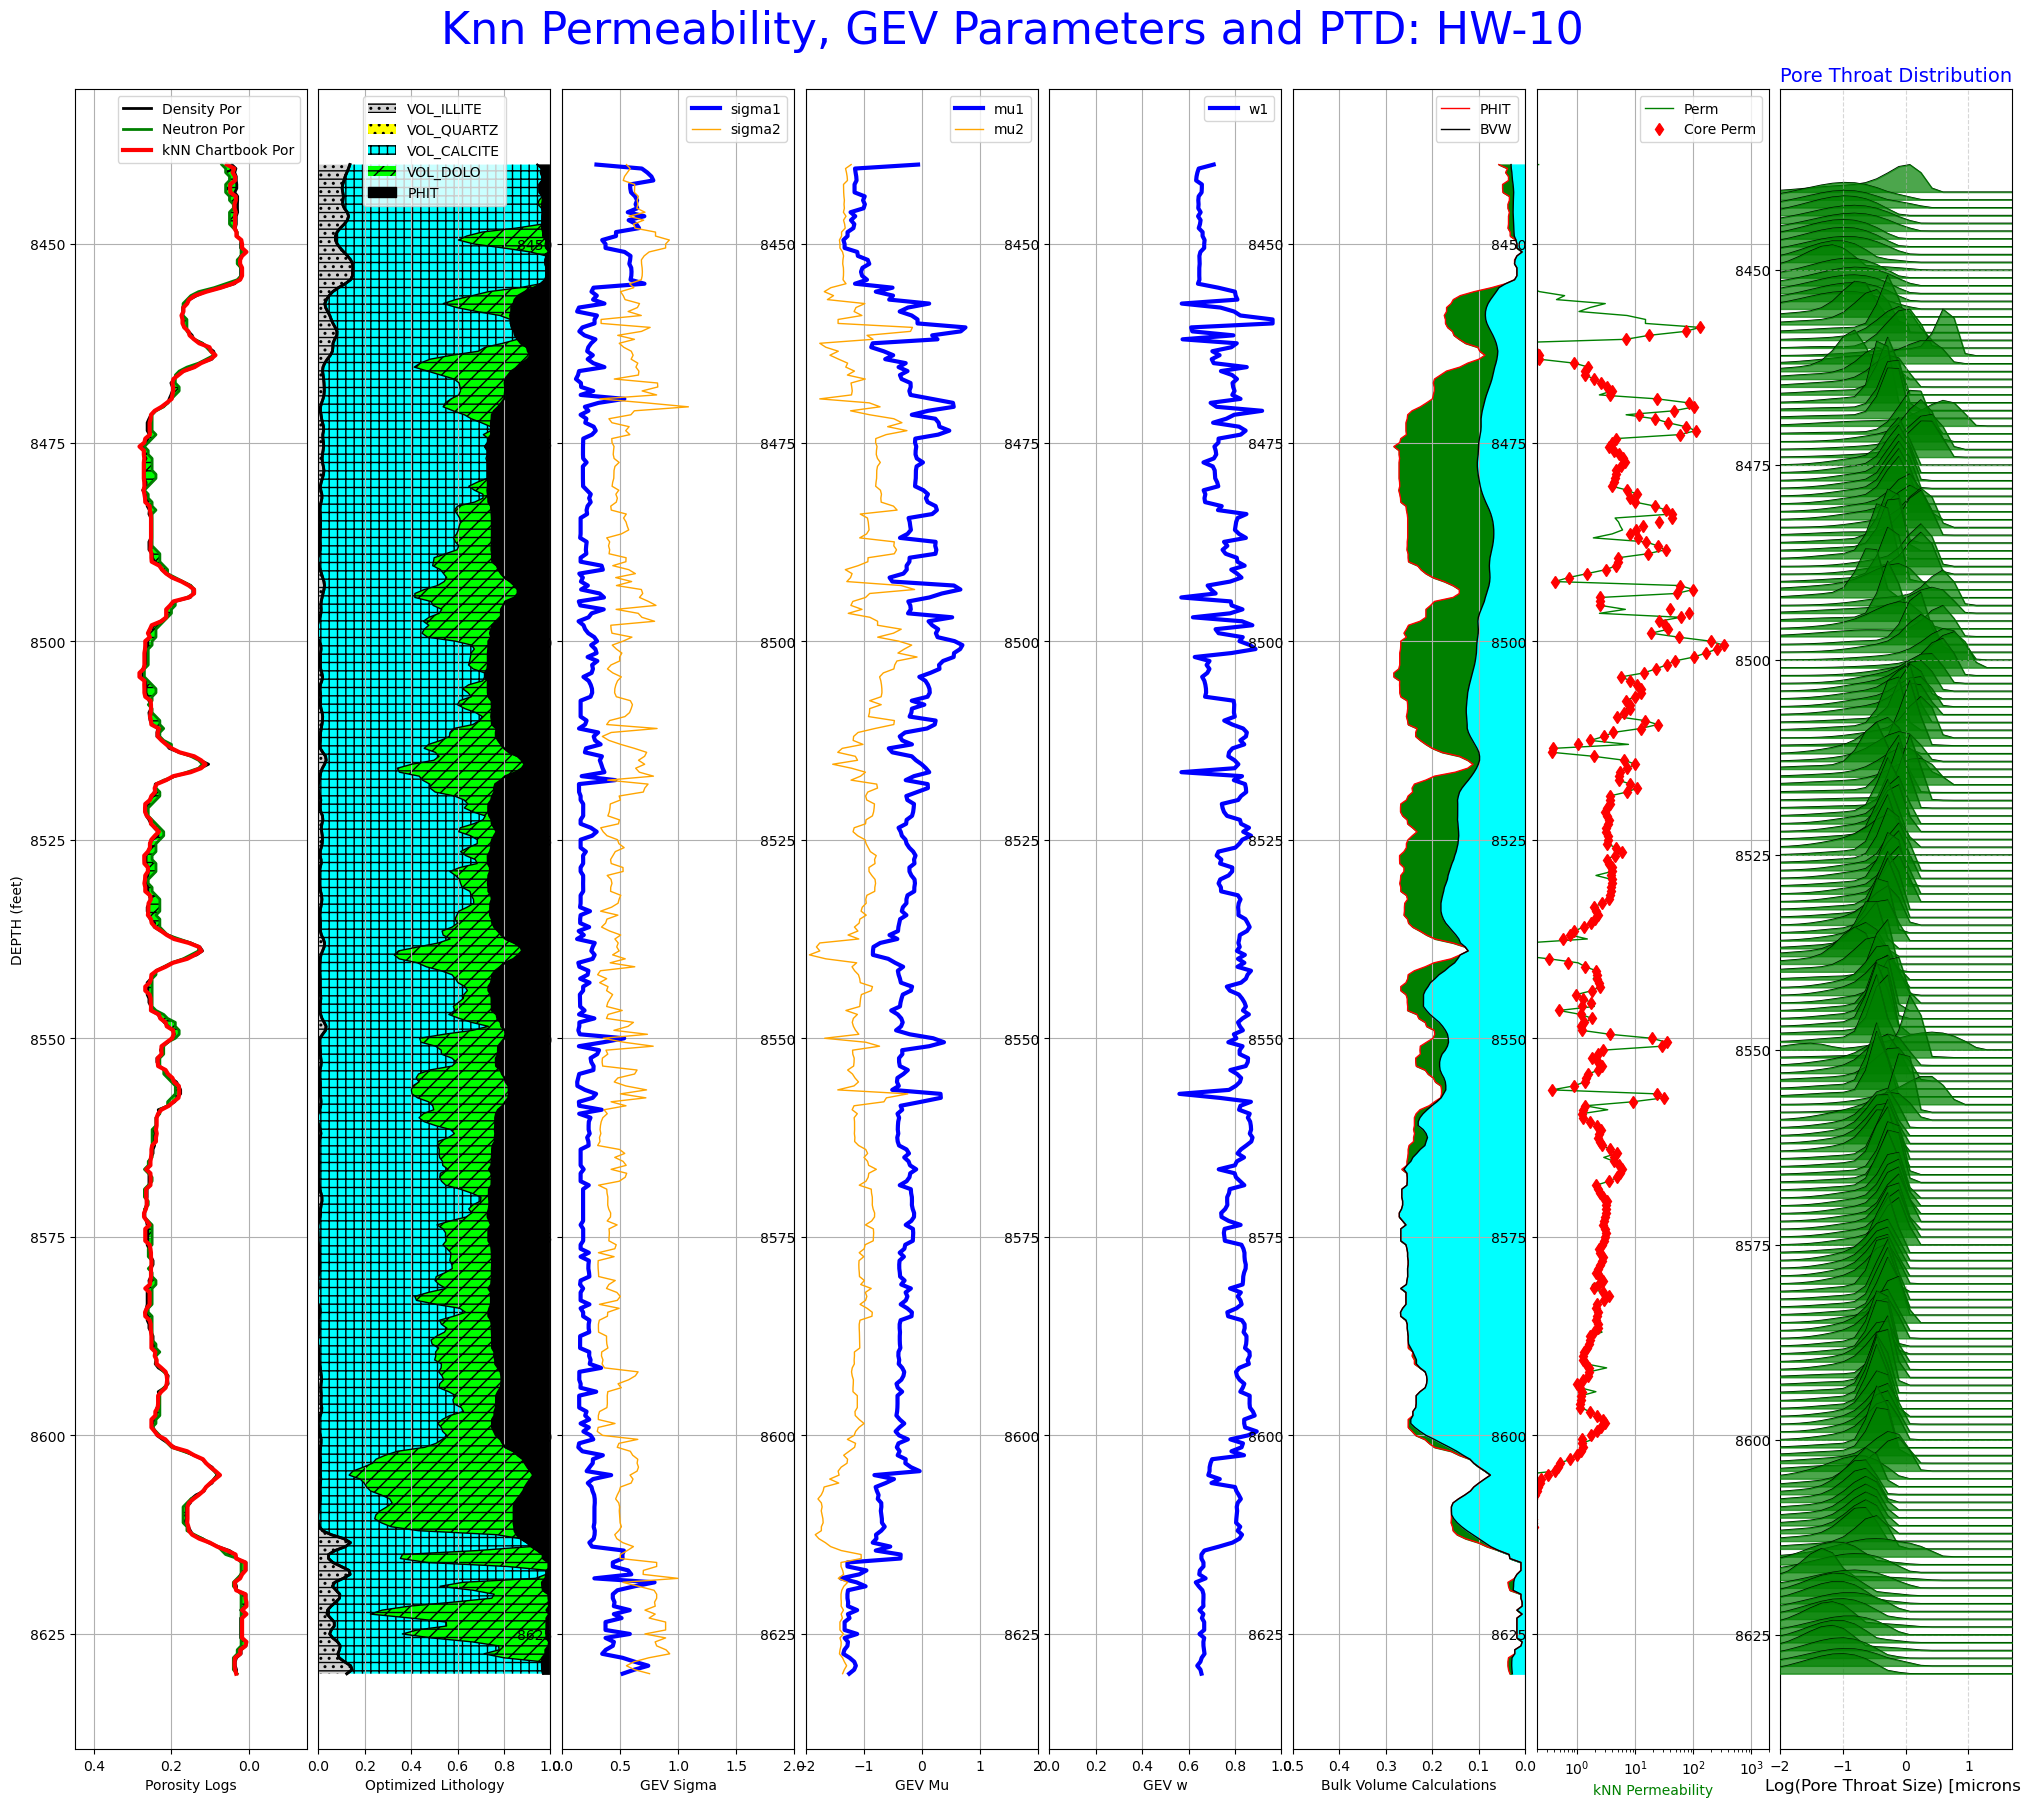

In [32]:
def PTD_plot():

    fig = plt.figure(figsize=(25,20))
    #fig.subplots_adjust(top=0.94,wspace=0.05, hspace =0.1)
    wellname=las.well.well.value
    fig.suptitle('Knn Permeability, GEV Parameters and PTD: %s'%wellname, fontsize=32, color='blue')
    fig.subplots_adjust(top=0.94, wspace=0.05, hspace =0.1)

    gs = gridspec.GridSpec(1, 8)
    ax1 = fig.add_subplot(gs[:,0])
    ax2 = fig.add_subplot(gs[0,1])
    ax3 = fig.add_subplot(gs[0,2])
    ax4 = fig.add_subplot(gs[0,3])
    ax5 = fig.add_subplot(gs[0,4])
    ax6 = fig.add_subplot(gs[0,5])
    ax7 = fig.add_subplot(gs[0,6])
    ax8 = fig.add_subplot(gs[0,7])

    y=np.array(deptharray)

    # Porosity Logs
    ax1.plot(porden, y,'-k',lw=2, label= 'Density Por')
    ax1.plot(CNL, y,'-g', lw=2, label= 'Neutron Por')
    ax1.plot(porarray, y,'-r',lw=3, label= 'kNN Chartbook Por')
    ax1.set_xlabel("Porosity Logs",color='black')
    ax1.set_ylabel('DEPTH (feet)')
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_xlim(.45, -0.15)
    ax1.fill_betweenx(y,CNL,porden, facecolor='#00ff00', hatch='--//')#, label= 'VOL_DOLO')
    ax1.legend()

    # Lithology
    quartz=np.array(VOL_QUARTZ)
    calcite=np.array(VOL_CALCITE)
    dolo=np.array(VOL_DOLO)
    illite=np.array(VOL_ILLITE)

    ax2.plot(illite, y,'-k',lw=2)
    ax2.plot(illite+quartz, y,'-k',lw=2)
    ax2.plot(illite+quartz+calcite, y,'-k',lw=1)
    ax2.plot(illite+quartz+calcite+dolo, y,'-k')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel(('Optimized Lithology'), color='black')
    ax2.fill_betweenx(y,0,illite, facecolor='#d1d1d1' ,hatch='.-.-',label= 'VOL_ILLITE')
    ax2.fill_betweenx(y,illite,illite+quartz, facecolor='#ffff00' ,hatch='..',label= 'VOL_QUARTZ')
    ax2.fill_betweenx(y,illite+quartz,illite+quartz+calcite, facecolor='#00ffff' ,hatch='++',label= 'VOL_CALCITE')
    ax2.fill_betweenx(y,illite+quartz+calcite,illite+quartz+calcite+dolo, facecolor='#00ff00', hatch='--//', label= 'VOL_DOLO')
    ax2.fill_betweenx(y,illite+quartz+calcite+dolo,1,color='black', label= 'PHIT')
    ax2.legend()
    #ax2=ax[2].twiny()
    ax2.invert_yaxis()
    ax2.grid(True)
    #ax2.set_ylabel('DEPTH (feet)')
    ax2.get_yaxis().set_visible(False)

    # sigmas
    sigma1=np.array(sigma1_est_knn)
    sigma2=np.array(sigma2_est_knn)

    # BVocc Depth Track
    ax3.plot(sigma1, y,'-b', lw=3, label= 'sigma1')
    ax3.plot(sigma2,y,'-', color='orange',lw=1, label= 'sigma2')
    #ax3.plot(BVocc2+BVocc1,y,'-b',lw=1, label= 'BVocc 1')

    ax3.set_xlabel("GEV Sigma",color='black')
    ax3.set_xlim(0, 2.0)
    #ax3.fill_betweenx(y,BVocc2,BVocc1+BVocc2, color='cyan')#, label= 'VOL_DOLO')
    #ax3.fill_betweenx(y,0,bv2_est_knn, color='orange')#, label= 'VOL_DOLO')
    #ax3.get_yaxis().set_visible(False)
    ax3.legend()
    ax3.invert_yaxis()
    ax3.grid(True)

    # mu's
    mu1=np.array(mu1_est_knn)
    mu2=np.array(mu2_est_knn)

    # Pd Track
    ax4.plot(mu1, y,'-b', lw=3, label= 'mu1')
    ax4.plot(mu2, y,'-',color='orange', lw=1, label= 'mu2')
    ax4.set_xlabel("GEV Mu",color='black')
    ax4.set_xlim(-2, 2)
    ax4.legend()
    ax4.invert_yaxis()
    ax4.grid(True)
    #ax4.set_ylabel('DEPTH (feet)')

    # weights
    w1=np.array(w1_est_knn)
    w2=np.array(w2_est_knn)

    # Thomeer G
    ax5.plot(w1, y,'-b', lw=3, label= 'w1')
    #ax5.plot(w2, y,'-k', lw=1, label= 'w2')
    ax5.set_xlabel("GEV w",color='black')
    ax5.set_xlim(0, 1.0)
    ax5.legend()
    ax5.invert_yaxis()
    ax5.grid(True)

    # Error Theoretical vs. Actual normalized logs

    ax6.plot(porarray, y,'-r', lw=1, label= 'PHIT')
    ax6.plot(bvw, y,'-k', lw=1, label= 'BVW')
    ax6.set_xlabel("Bulk Volume Calculations",color='black')
    ax6.set_xlim(0.5, 0.0)
    ax6.fill_betweenx(y,porarray,bvw, color='green')#, label= 'VOL_DOLO')
    ax6.fill_betweenx(y,bvw,0, color='cyan')#, label= 'VOL_DOLO')
    ax6.legend()
    ax6.invert_yaxis()
    ax6.grid(True)

    # Permeability
    ax7.semilogx(perm, y,'-g', lw=1, label= 'Perm')
    ax7.semilogx(df_log['CORE_PERM'], y,'rd', lw=1, label= 'Core Perm')
    #########ax7.semilogx(Perm_Mode_xi, y,'-.b', lw=1, label= 'GEV Perm')
    ax7.set_xlabel("kNN Permeability",color='green')
    ax7.set_xlim(0.2, 2000.0)
    ax7.legend()
    ax7.invert_yaxis()
    ax7.grid(True)


    
    n = 2  # Plot every nth distribution
    reduced_pt_dist = micronarray_all[::n]
    reduced_dbv_dist = dbvarray_all[::n]
    reduced_depth_array = y[::n]

    for i, (microns, dbvs) in enumerate(zip(reversed(reduced_pt_dist), reversed(reduced_dbv_dist))):
        microns_x = np.log10(microns)  # Log scale for pore throat sizes
        depth = reduced_depth_array[-(i + 1)]

        # Plot the distribution line
        ax8.plot(microns_x, (depth - dbvs), color="k", linewidth=0.75, zorder=100 - i)

        # Fill the area under the distribution
        ax8.fill_between(microns_x, depth, depth - dbvs, color="green", alpha=0.7, zorder=100 - i)

    # PTD plot settings
    ax8.set_xlabel("Log(Pore Throat Size) [microns]", fontsize=12)
    ax8.set_title("Pore Throat Distribution", color = 'blue', fontsize=14)
    ax8.set_xlim(np.log10(0.01), np.log10(50))
    #ax8.set_ylim(depth_max, depth_min)  # Shallow on top, deep on bottom
    ax8.invert_yaxis()
    ax8.grid(True, linestyle="--", alpha=0.5)



PTD_plot()

# 7) GEV Gaussian Capillary Pressure Bulk Volume Oil (BVO) Calculations:

## Free Water Level (FWL) Search
We have provided a FWL Search technique in python too to estimate the FWL elevation (TVDss) in each key well to be used to create a FWL plane for the field. To model Capillary Pressure saturations, it is essential to have a proper Free Water Level (FWL). Reservoir Capillary Pressure or buoyancy is dependent upon the height above the FWL.

On new discoveries the FWL is usually determined from Formation Test data plotting the pressure data vs. TVDss to find the intersection of the water gradient vs. hydrocarbon gradient. The elevation of this intersection is the FWL or zero Capillary Pressure. However, on older fields, this type of data is typically not available prior to pressure depletion and/or fluid contact movements in the field. Therefore, we need another way to estimate the FWL for the field. In the python software used in our Notebook we offer a FWL search technique that has been shown to work very well in numerous fields.

We perform this well-by-well FWL search by varying the FWL elevation from an estimated highest FWL to the lowest expected FWL (spill point...) for the reservoir.  We then calculate the error difference between the Bulk Volume Oil (BVO) from logs vs. BVO from GEV Capillary Pressure at each new FWL estimate for that well. The final fwl_est is the FWL estimated with the lowest Bulk Volume Oil (BVO) error for that well. This fwl_est is then used in our final GEV BVO Oil calculations.

The FWL search is usually run on all wells with a fwl_est for each well. In many instances in fields with large hydrocarbon columns, the wells near the crest will be too high above the FWL to give valid results. We have found that the wells near the edge usually give the best estimation. However, those wells affected by water encroachment will also not give valid results. In the end it is usually a small percentage of wells near the edge of the field that will give valid FWL estimates that are consistent. The search results from these wells are then typically used to construct a plane in the 3D fine-grid model to represent the FWL for the field.

It should be noted, that not all FWL surfaces are flat. Structural tilting, subduction, and dynamic aquifers... can result in a tilted FWL elevations with the possibility of residual oil below the FWL, depending in the situation.

In [33]:
print(elev_meas_ref)

397


In [34]:
#elev_meas_ref = 397

tcosthetaww = 14
rho_f = 1.135
rho_hc = 0.837

IFTheta = 372



bvo_error_temp=222
#fwl_est = 8100

FWL_UPPER_ESTIMATE = 8100
FWL_LOWER_ESTIMATE = 8300

# loop through FWL Search from 8100 to 8300 steps
for fwl in range(FWL_UPPER_ESTIMATE, FWL_LOWER_ESTIMATE,2):


    h=[]
    PcRes=[]
    PcHg=[]
    por_upscale_fact=[]
    bvo_gev=[]
    sw_gev=[]
    
    bvo_error=[]
    bvo_error_sum=0
    bvo_error_level=[]
    
    
    # Load log data from df
    for k in range(0,len(df_log) ,1):
    
        # =============================================================================
        # # ===========================================================================
        # # #--------------------------------------------------------------------------
        # # #
        # # #            Calculate GEV-based BVO Saturations
        # # #
        # # #--------------------------------------------------------------------------
        # # ===========================================================================
        # =============================================================================
     

        
        h.append(fwl - (Dep[k]-elev_meas_ref))  # height above FWL
    
    
        #PcRes.append(h[k] *0.433*(rho_f - rho_hc))
        #PcHg.append((IFTheta/tcosthetaww)*PcRes[k])




        # Calculate reservoir and Hg capillary pressures
        PcRes_k = h[k] * 0.433 * (rho_f - rho_hc)
        if PcRes_k < 0:  # Below FWL
            PcHg_k = 0
        else:
            PcHg_k = IFTheta * PcRes_k / tcosthetaww
    
        PcRes.append(PcRes_k)
        PcHg.append(PcHg_k)
    
        # Calculate radius in microns
        if PcHg_k > 0:
            Rc = 2 * IFTheta * 0.147 / PcHg_k
        else:
            Rc = np.inf  # Set Rc to a very large value if PcHg is 0
    
        if PcHg_k == 0:  # Below FWL
            Sw1 = 1
        else:
            Rc_log = np.log10(Rc)  # or -log10(Rc), depending on your convention
            Sw1 = np.clip(
                w1_est_knn[k] * genextreme.cdf(Rc_log, c=0.5, loc=mu1_est_knn[k], scale=sigma1_est_knn[k] * 2) +
                w2_est_knn[k] * genextreme.cdf(Rc_log, c=0.5, loc=mu2_est_knn[k], scale=sigma2_est_knn[k]),
                0,
                1
            )
 

        #-------------      Upscale Porosity Correction Factor       ------------------------

        #por_upscale_fact.append((0.1629 * math.log(porarray[k]) + 1.2923)  )
        por_upscale_fact.append( 1)
    
    
        #---------   Calculate BVO and Sw  ------------------------------------------------
        bvo_gev.append( (por_upscale_fact[k] * (porarray[k] * (1 - Sw1))))
        sw_gev.append(Sw1)

    
        #---------   Calculate BVO and Sw  ------------------------------------------------
        #bvo_gev.append(  (porarray[k] * (1 - Sw1)))
        sw_gev.append(Sw1)
    
        bvo_error.append(abs(bvo[k]-bvo_gev[k]))

        bvo_error_sum=(bvo_error_sum + bvo_error[k])
        
    #print('h=',h[k])
    

    if bvo_error_sum<bvo_error_temp:
        fwl_est = fwl
    

    print('FWL Try=',fwl,'\t','BVO_Error_Sum =', bvo_error_sum,'\t','fwl_est =',fwl_est)

    bvo_error_temp=bvo_error_sum
    
print()
print()
print('Final FWL Estimate:', fwl_est)

FWL Try= 8100 	 BVO_Error_Sum = 17.94635215135264 	 fwl_est = 8100
FWL Try= 8102 	 BVO_Error_Sum = 17.506019251343837 	 fwl_est = 8102
FWL Try= 8104 	 BVO_Error_Sum = 17.112444301032966 	 fwl_est = 8104
FWL Try= 8106 	 BVO_Error_Sum = 16.504738193830743 	 fwl_est = 8106
FWL Try= 8108 	 BVO_Error_Sum = 15.839855582829562 	 fwl_est = 8108
FWL Try= 8110 	 BVO_Error_Sum = 15.2209682211623 	 fwl_est = 8110
FWL Try= 8112 	 BVO_Error_Sum = 14.66134276826424 	 fwl_est = 8112
FWL Try= 8114 	 BVO_Error_Sum = 14.14216323416985 	 fwl_est = 8114
FWL Try= 8116 	 BVO_Error_Sum = 13.643513751270842 	 fwl_est = 8116
FWL Try= 8118 	 BVO_Error_Sum = 13.165357999040546 	 fwl_est = 8118
FWL Try= 8120 	 BVO_Error_Sum = 12.696397252732305 	 fwl_est = 8120
FWL Try= 8122 	 BVO_Error_Sum = 12.236547765398779 	 fwl_est = 8122
FWL Try= 8124 	 BVO_Error_Sum = 11.774664716973263 	 fwl_est = 8124
FWL Try= 8126 	 BVO_Error_Sum = 11.390860304103896 	 fwl_est = 8126
FWL Try= 8128 	 BVO_Error_Sum = 11.047616240637891 	 

In [47]:
def BVO_plot():
    fig = plt.figure(figsize=(18,15))
    #fig.subplots_adjust(top=0.94,wspace=0.05, hspace =0.1)
    wellname=las.well.well.value
    fig.suptitle('GEV Gaussian Parameters and GEV BVO from Pc: %s'%wellname, fontsize=32, color='blue')#,y=0.9)
    fig.subplots_adjust(top=0.94,wspace=0.05, hspace =0.1)


    gs = gridspec.GridSpec(1, 9)
    ax1 = fig.add_subplot(gs[:,0])
    ax2 = fig.add_subplot(gs[0,1])
    ax3 = fig.add_subplot(gs[0,2])
    ax4 = fig.add_subplot(gs[0,3])
    ax5 = fig.add_subplot(gs[0,4])
    ax6 = fig.add_subplot(gs[0,5])
    ax7 = fig.add_subplot(gs[0,6])
    ax8 = fig.add_subplot(gs[0,7])
    ax9 = fig.add_subplot(gs[0,8])

    y=np.array(deptharray)

    # Porosity Logs
    ax1.plot(porden, y,'-k',lw=2, label= 'Density Por')
    ax1.plot(CNL, y,'-g', lw=2, label= 'Neutron Por')
    ax1.plot(porarray, y,'-r',lw=3, label= 'kNN Chartbook Por')
    ax1.set_xlabel("Porosity Logs",color='black')
    ax1.set_ylabel('DEPTH (feet)')
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_xlim(.45, -0.15)
    ax1.fill_betweenx(y,CNL,porden, facecolor='#00ff00', hatch='--//')#, label= 'VOL_DOLO')
    ax1.legend()

    # Lithology
    quartz=np.array(VOL_QUARTZ)
    calcite=np.array(VOL_CALCITE)
    dolo=np.array(VOL_DOLO)
    illite=np.array(VOL_ILLITE)

    ax2.plot(illite, y,'-k',lw=2)
    ax2.plot(illite+quartz, y,'-k',lw=2)
    ax2.plot(illite+quartz+calcite, y,'-k',lw=1)
    ax2.plot(illite+quartz+calcite+dolo, y,'-k')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel(('Optimized Lithology'), color='black')
    ax2.fill_betweenx(y,0,illite, facecolor='#d1d1d1' ,hatch='.-.-',label= 'VOL_ILLITE')
    ax2.fill_betweenx(y,illite,illite+quartz, facecolor='#ffff00' ,hatch='..',label= 'VOL_QUARTZ')
    ax2.fill_betweenx(y,illite+quartz,illite+quartz+calcite, facecolor='#00ffff' ,hatch='++',label= 'VOL_CALCITE')
    ax2.fill_betweenx(y,illite+quartz+calcite,illite+quartz+calcite+dolo, facecolor='#00ff00', hatch='--//', label= 'VOL_DOLO')
    ax2.fill_betweenx(y,illite+quartz+calcite+dolo,1,color='black', label= 'PHIT')
    ax2.legend()
    #ax2=ax[2].twiny()
    ax2.invert_yaxis()
    ax2.grid(True)
    #ax2.set_ylabel('DEPTH (feet)')
    ax2.get_yaxis().set_visible(False)

    # GEV Sigmas
    sigma1=np.array(sigma1_est_knn)
    sigma2=np.array(sigma2_est_knn)

    # BVocc Depth Track
    ax3.plot(sigma1, y,'-b', lw=3, label= 'sigma1')
    ax3.plot(sigma2,y,'-', color='orange', lw=1, label= 'sigma2')
    #ax3.plot(BVocc2+BVocc1,y,'-b',lw=1, label= 'BVocc 1')

    ax3.set_xlabel("GEV Sigma",color='black')
    ax3.set_xlim(0, 2.0)
    #ax3.fill_betweenx(y,BVocc2,BVocc1+BVocc2, color='cyan')#, label= 'VOL_DOLO')
    #ax3.fill_betweenx(y,0,bv2_est_knn, color='orange')#, label= 'VOL_DOLO')
    #ax3.get_yaxis().set_visible(False)
    ax3.legend()
    ax3.invert_yaxis()
    ax3.grid(True)

    # GEV mu's
    mu1=np.array(mu1_est_knn)
    mu2=np.array(mu2_est_knn)

    # GEV Track
    ax4.plot(mu1, y,'-b', lw=3, label= 'mu1')
    ax4.plot(mu2, y,'-',color='orange', lw=1, label= 'mu2')
    ax4.set_xlabel("GEV Mu",color='black')
    ax4.set_xlim(-2, 2)
    ax4.legend()
    ax4.invert_yaxis()
    ax4.grid(True)
    #ax4.set_ylabel('DEPTH (feet)')

    # GEV w
    w1=np.array(w1_est_knn)
    w2=np.array(w2_est_knn)

    # GEV w
    ax5.plot(w1, y,'-b', lw=3, label= 'w1')
    #ax5.plot(w2, y,'-k', lw=1, label= 'w2')
    ax5.set_xlabel("GEV w",color='black')
    ax5.set_xlim(0, 1.0)
    ax5.legend()
    ax5.invert_yaxis()
    ax5.grid(True)

    
    # Error Theoretical vs. Actual normalized logs
    ax6.plot(porarray, y,'-r', lw=1, label= 'PHIT')
    ax6.plot(bvw, y,'-k', lw=1, label= 'BVW')
    ax6.set_xlabel("Bulk Volume Calculations",color='black')
    ax6.set_xlim(0.5, 0.0)
    ax6.fill_betweenx(y,porarray,bvw, color='green')#, label= 'VOL_DOLO')
    ax6.fill_betweenx(y,bvw,0, color='cyan')#, label= 'VOL_DOLO')
    ax6.legend()
    ax6.invert_yaxis()
    ax6.grid(True)
    

    # Permeability
    ax7.semilogx(perm, y,'-g', lw=1, label= 'Perm')
    ax7.semilogx(df_log['CORE_PERM'], y,'rd', lw=1, label= 'Core Perm')
    #########ax7.semilogx(Perm_Mode_xi, y,'-.b', lw=1, label= 'GEV Perm')
    ax7.set_xlabel("kNN Permeability",color='green')
    ax7.set_xlim(0.2, 2000.0)
    ax7.legend()
    ax7.invert_yaxis()
    ax7.grid(True)

    # GEV BVO
    ax8.plot(bvo, y,'-', color='olive', lw=4, label= 'BVO logs')
    ax8.plot(bvo_gev, y,'-', color='magenta', lw=3, label= 'BVO GEV Pc')
    ax8.set_xlabel("GEV BVO",color='black')
    ax8.set_xlim(0.0, 0.4)
    ax8.legend()
    ax8.invert_yaxis()
    ax8.grid(True)


    # -------- PTD: vertical wiggles (height = amplitude), aligned to depth --------
    n = 2  # plot every nth depth
    depths   = np.asarray(y)[::n]
    ptd_x    = micronarray_all[::n]   # list/array of microns per depth
    ptd_amp  = dbvarray_all[::n]      # same shape; amplitudes
    
    # axis limits for x
    ax9.set_xlim(np.log10(0.01), np.log10(50.0))
    
    # simple, robust vertical scale so wiggles are visible
    all_amp = np.concatenate([np.asarray(a).ravel() for a in ptd_amp if len(a)])
    max_amp = np.nanpercentile(all_amp, 95) if all_amp.size else 1.0
    scale_y = (4.0 / max_amp)  # ~4 ft max lobe height; increase if needed
    
    for depth, microns, amps in zip(depths, ptd_x, ptd_amp):
        microns = np.asarray(microns); amps = np.asarray(amps)
        if microns.size < 2 or amps.size != microns.size: 
            continue
        xx = np.log10(microns)
        # vertical wiggle: y varies with amplitude, x is log10(microns)
        y_base = np.full_like(xx, depth, dtype=float)
        y_top  = (depth - scale_y * amps)
        ax9.fill_between(xx, y_base, y_top, color="green", alpha=0.7)
        ax9.plot(xx, y_top, color="black",alpha=0.7, lw=0.5)
    
    ax9.set_xlabel("Log(Pore Throat Size) [μm]")
    ax9.set_title("PTD", color='blue')
    ax9.invert_yaxis()
    ax9.grid(True, linestyle="--", alpha=0.4)
    


    os.makedirs("./plots", exist_ok=True)
    save_dir = "./plots"
 
    # Save the figure with well name in filename
    save_path = os.path.join(save_dir, f"Dept_Plot_{wellname}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')



### Final GEV BVO calculations from the FWL Search results:

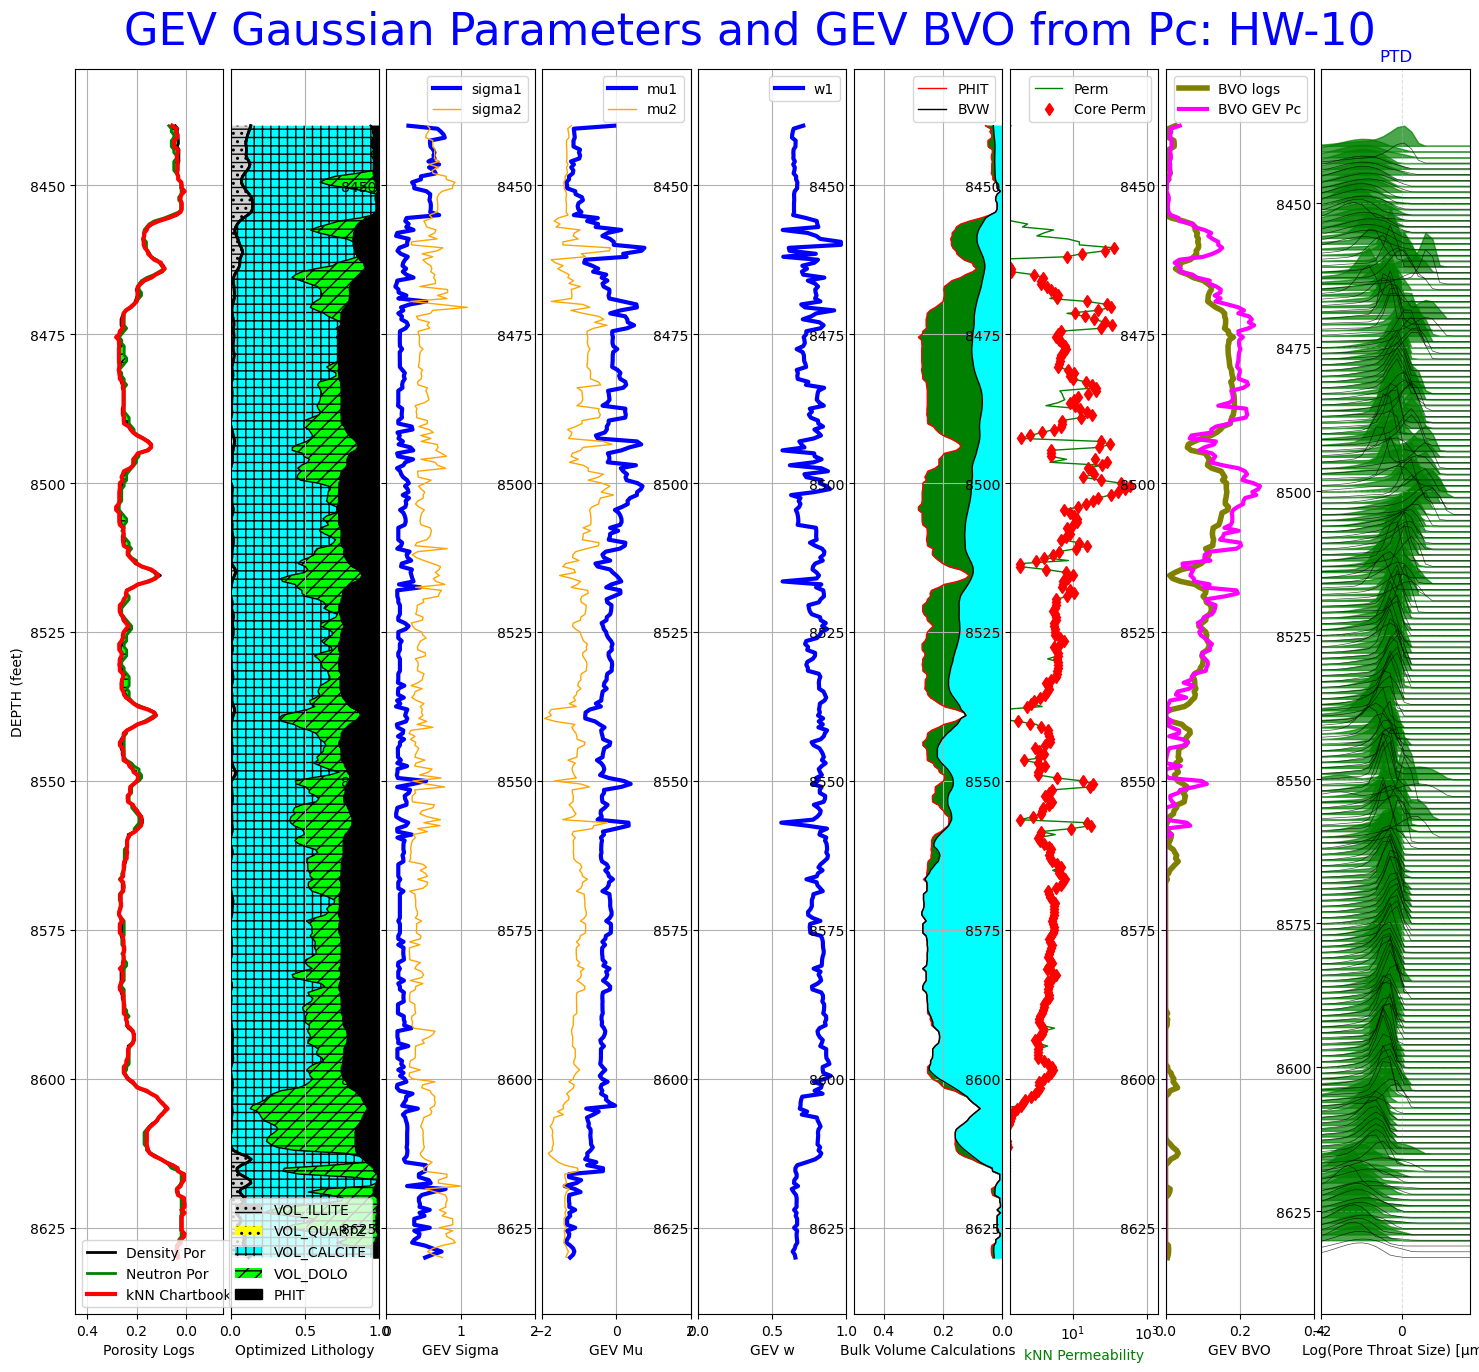

In [48]:
h=[]
PcRes=[]
PcHg=[]
por_upscale_fact=[]
bvocc1=[]
bvocc2=[]
bvo_gev=[]
sw_gev=[]
Jfun = []


BVO_thomeer=[]
 
BVO_J = []
BVO_cb = []
BVO_table = []
BVO_perm = []
BVO_sh = []
BVO_lam = []
BVO_cud = []
BVO_caplog = []

IFTheta = 372
tcosthetaww = 14

fwl=fwl_est
#fwl=8172

# Load log data from df
for k in range(0,len(df_log) ,1):

    # =============================================================================
    # # ===========================================================================
    # # #--------------------------------------------------------------------------
    # # #
    # # #            Calculate GEV-based BVO Saturations
    # # #
    # # #--------------------------------------------------------------------------
    # # ===========================================================================
    # =============================================================================

  
    h.append(fwl - (Dep[k]-elev_meas_ref))  # height above FWL


    # Calculate reservoir and Hg capillary pressures
    PcRes_k = h[k] * 0.433 * (rho_f - rho_hc)
    if PcRes_k < 0:  # Below FWL
        PcHg_k = 0
    else:
        PcHg_k = IFTheta * PcRes_k / tcosthetaww

    PcRes.append(PcRes_k)
    PcHg.append(PcHg_k)

    # Calculate radius in microns
    if PcHg_k > 0:
        Rc = 2 * IFTheta * 0.147 / PcHg_k
    else:
        Rc = np.inf  # Set Rc to a very large value if PcHg is 0


    # GEV Gaussian   
    if PcHg_k == 0:  # Below FWL
        Sw1 = 1
    else:
        Rc_log = np.log10(Rc)  # or -log10(Rc), depending on your convention
        Sw1 = np.clip(
            w1_est_knn[k] * genextreme.cdf(Rc_log, c=0.5, loc=mu1_est_knn[k], scale=sigma1_est_knn[k] * 2) +
            w2_est_knn[k] * genextreme.cdf(Rc_log, c=0.5, loc=mu2_est_knn[k], scale=sigma2_est_knn[k]),
            0,
            1
        )

    

    #---------   Calculate BVO and Sw  ------------------------------------------------
    bvo_gev.append( ( (porarray[k] * (1 - Sw1)))   )
    sw_gev.append(Sw1)




'''
# =============================================================================
#      Display BVO from GEV parameters and FWL Search
# ============================================================================='''
BVO_plot()